# 2. Preprocessing and EDA

In [172]:
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

In [173]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
# libraries for displaying images
from IPython.display import Image 
from IPython.core.display import HTML 
from folium.plugins import FloatImage
import folium # plotting library for maps
# from utility.utils import setup_autosave, save_plot

# Plotly
from plotly.offline import init_notebook_mode, iplot, plot
import plotly.graph_objs as go
init_notebook_mode(connected=True)
%matplotlib inline

In [174]:
## loading the dataset
import joblib
df = joblib.load('/Users/mac/Desktop/Desktop_Files/Projects/Zomato Restaurant Rating Prediction/artifacts/cleaned_data.pkl')

In [175]:
df.shape

(36711, 12)

In [176]:
df.head()

,name,online_order,book_table,rate,votes,location,rest_type,cuisines,average_cost,reviews_list,menu_item,listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800,"[(Rated 4.0, RATED\n A beautiful place to din...",[],Buffet
1,Spice Elephant,Yes,No,4.1,787,Banashankari,Casual Dining,"Chinese, North Indian, Thai",800,"[(Rated 4.0, RATED\n Had been here for dinner...",[],Buffet
2,San Churro Cafe,Yes,No,3.8,918,Banashankari,"Cafe, Casual Dining","Cafe, Mexican, Italian",800,"[(Rated 3.0, RATED\n Ambience is not that goo...",[],Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,Banashankari,Quick Bites,"South Indian, North Indian",300,"[(Rated 4.0, RATED\n Great food and proper Ka...",[],Buffet
4,Grand Village,No,No,3.8,166,Basavanagudi,Casual Dining,"North Indian, Rajasthani",600,"[(Rated 4.0, RATED\n Very good restaurant in ...",[],Buffet


In [177]:
df.isnull().sum()

name               0
online_order       0
book_table         0
rate               0
votes              0
location           0
rest_type          0
cuisines           0
average_cost       0
reviews_list       0
menu_item          0
listed_in(type)    0
dtype: int64

In [178]:
# Changing some columns names for better understanding
df=df.rename(columns={'listed_in(type)':'type', 'average_cost' : 'approx_cost'})


In [179]:
df.head()

,name,online_order,book_table,rate,votes,location,rest_type,cuisines,approx_cost,reviews_list,menu_item,type
0,Jalsa,Yes,Yes,4.1,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800,"[(Rated 4.0, RATED\n A beautiful place to din...",[],Buffet
1,Spice Elephant,Yes,No,4.1,787,Banashankari,Casual Dining,"Chinese, North Indian, Thai",800,"[(Rated 4.0, RATED\n Had been here for dinner...",[],Buffet
2,San Churro Cafe,Yes,No,3.8,918,Banashankari,"Cafe, Casual Dining","Cafe, Mexican, Italian",800,"[(Rated 3.0, RATED\n Ambience is not that goo...",[],Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,Banashankari,Quick Bites,"South Indian, North Indian",300,"[(Rated 4.0, RATED\n Great food and proper Ka...",[],Buffet
4,Grand Village,No,No,3.8,166,Basavanagudi,Casual Dining,"North Indian, Rajasthani",600,"[(Rated 4.0, RATED\n Very good restaurant in ...",[],Buffet


In [180]:
df['approx_cost'].isnull().sum()

np.int64(0)

In [181]:
# description of the dataset
df.describe()

,rate,votes
count,36711.000000,36711.000000
mean,3.722519,383.251369
std,0.484145,930.628599
min,1.000000,0.000000
25%,3.400000,23.000000
50%,3.800000,82.000000
75%,4.000000,315.000000
max,5.000000,16832.000000


In [182]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 36711 entries, 0 to 51716
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   name          36711 non-null  object 
 1   online_order  36711 non-null  object 
 2   book_table    36711 non-null  object 
 3   rate          36711 non-null  float64
 4   votes         36711 non-null  int64  
 5   location      36711 non-null  object 
 6   rest_type     36711 non-null  object 
 7   cuisines      36711 non-null  object 
 8   approx_cost   36711 non-null  object 
 9   reviews_list  36711 non-null  object 
 10  menu_item     36711 non-null  object 
 11  type          36711 non-null  object 
dtypes: float64(1), int64(1), object(10)
memory usage: 3.6+ MB


In [183]:
df = df.drop(columns='menu_item', axis=1)

In [184]:
df.head()

,name,online_order,book_table,rate,votes,location,rest_type,cuisines,approx_cost,reviews_list,type
0,Jalsa,Yes,Yes,4.1,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800,"[(Rated 4.0, RATED\n A beautiful place to din...",Buffet
1,Spice Elephant,Yes,No,4.1,787,Banashankari,Casual Dining,"Chinese, North Indian, Thai",800,"[(Rated 4.0, RATED\n Had been here for dinner...",Buffet
2,San Churro Cafe,Yes,No,3.8,918,Banashankari,"Cafe, Casual Dining","Cafe, Mexican, Italian",800,"[(Rated 3.0, RATED\n Ambience is not that goo...",Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,Banashankari,Quick Bites,"South Indian, North Indian",300,"[(Rated 4.0, RATED\n Great food and proper Ka...",Buffet
4,Grand Village,No,No,3.8,166,Basavanagudi,Casual Dining,"North Indian, Rajasthani",600,"[(Rated 4.0, RATED\n Very good restaurant in ...",Buffet


### Auto saving visualization inside folder->
from utils.py

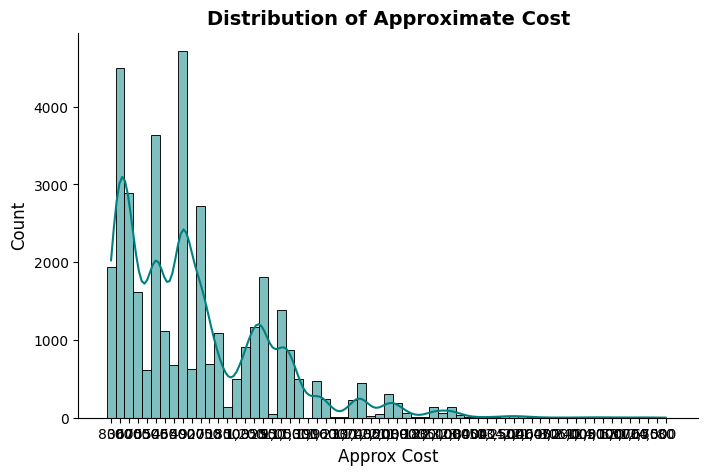

In [185]:
plt.figure(figsize=(8,5))
sns.histplot(df['approx_cost'], bins=30, kde=True, color='teal', edgecolor='black')
plt.title("Distribution of Approximate Cost", fontsize=14, fontweight='bold')
plt.xlabel("Approx Cost", fontsize=12)
plt.ylabel("Count", fontsize=12)
sns.despine()  # Remove top and right spines for a cleaner look (chatGPT suggestion) 
plt.show('approx_cost_distribution.png')

In [186]:
df.columns

Index(['name', 'online_order', 'book_table', 'rate', 'votes', 'location',
       'rest_type', 'cuisines', 'approx_cost', 'reviews_list', 'type'],
      dtype='object')

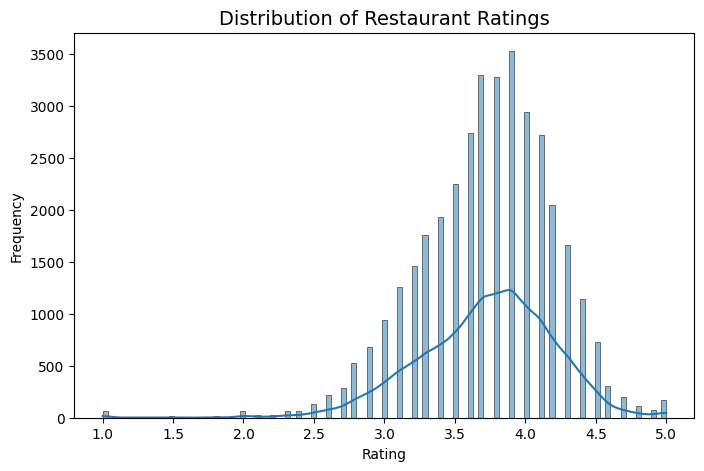

In [187]:
plt.figure(figsize=(8,5))
sns.histplot(df['rate'], kde=True, edgecolor='black')
plt.title("Distribution of Restaurant Ratings", fontsize=14)
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show("restaurant_ratings_distribution.png")

In [188]:
# checking skewness in the rate column
print('skewness->',df.rate.skew()) 
# checking blank values in rate column
df[df['rate']==""].shape[0]
# df['rate'].unique()

skewness-> -0.685720019230723


0

In [189]:
df.columns

Index(['name', 'online_order', 'book_table', 'rate', 'votes', 'location',
       'rest_type', 'cuisines', 'approx_cost', 'reviews_list', 'type'],
      dtype='object')

In [190]:
histo = df.groupby('name')['location'].count()
# Lets take the top 50 restaurantsand plot bar graph
histo = histo.sort_values()[-30:]

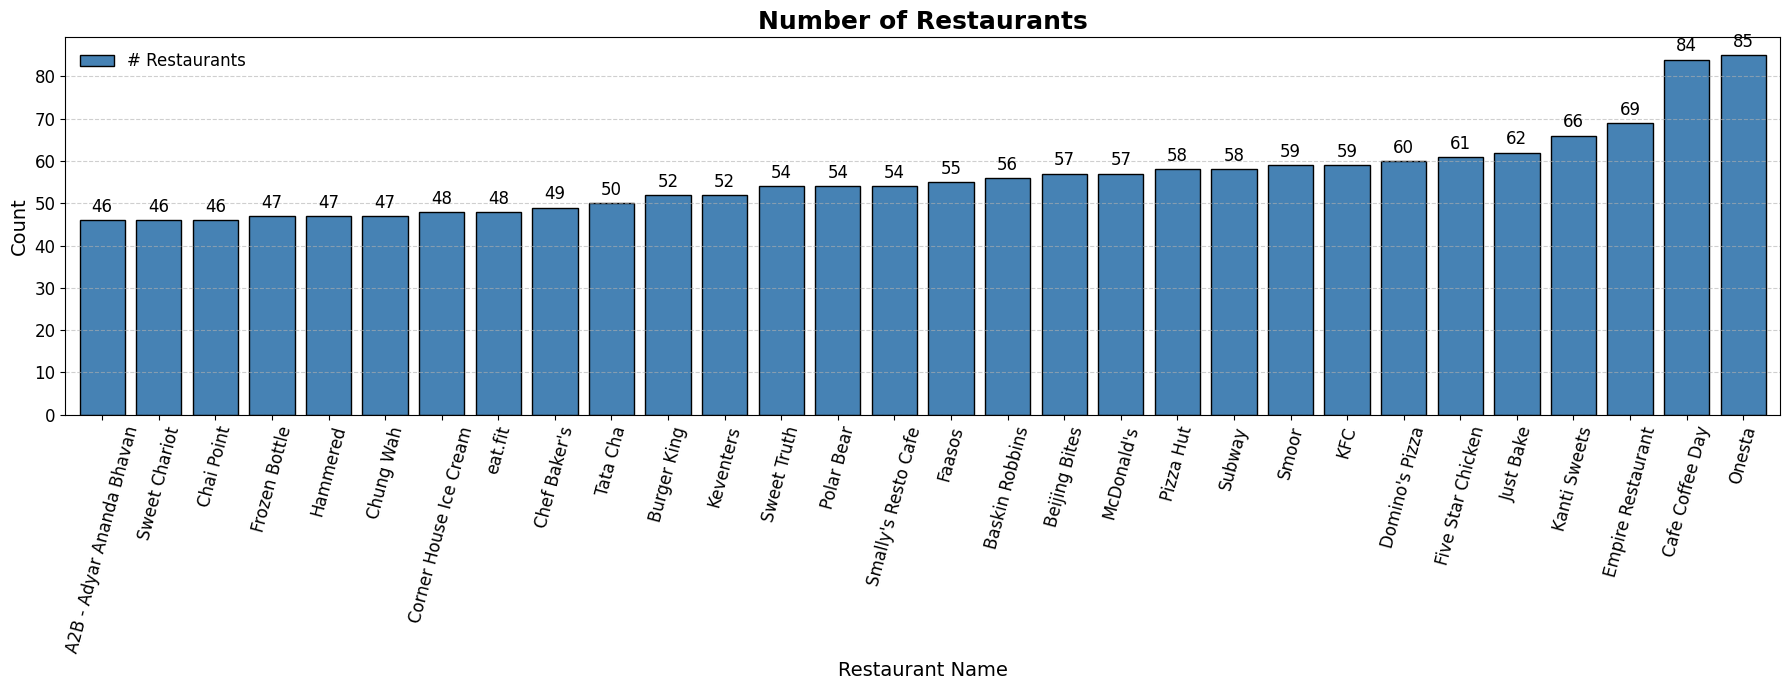

In [191]:
# Simple, beautiful, and professional bar plot
# used ChatGPT to beautify the plot->
ax = histo.plot(
    kind='bar',
    figsize=(18, 7),
    rot=75,
    width=0.8,
    color='steelblue',
    edgecolor='black'
)

# Add value labels on bars
for rect in ax.patches:
    ax.text(
        rect.get_x() + rect.get_width() / 2,
        rect.get_height() + 1,
        f'{int(rect.get_height())}',
        ha='center',
        va='bottom',
        fontsize=12,
        color='black'
    )

# Beautify the chart
ax.set_title('Number of Restaurants', fontsize=18, fontweight='bold')
ax.set_xlabel('Restaurant Name', fontsize=14)
ax.set_ylabel('Count', fontsize=14)
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.set_facecolor('white')
ax.grid(axis='y', linestyle='--', alpha=0.6)

# Simplified legend
ax.legend(['# Restaurants'], fontsize=12, frameon=False)

plt.tight_layout()
plt.show("top_30_restaurants_by_count.png")


- "Cafe Coffee Day" has literally 84 restaurants in Bengaluru!

### Word Cloud 

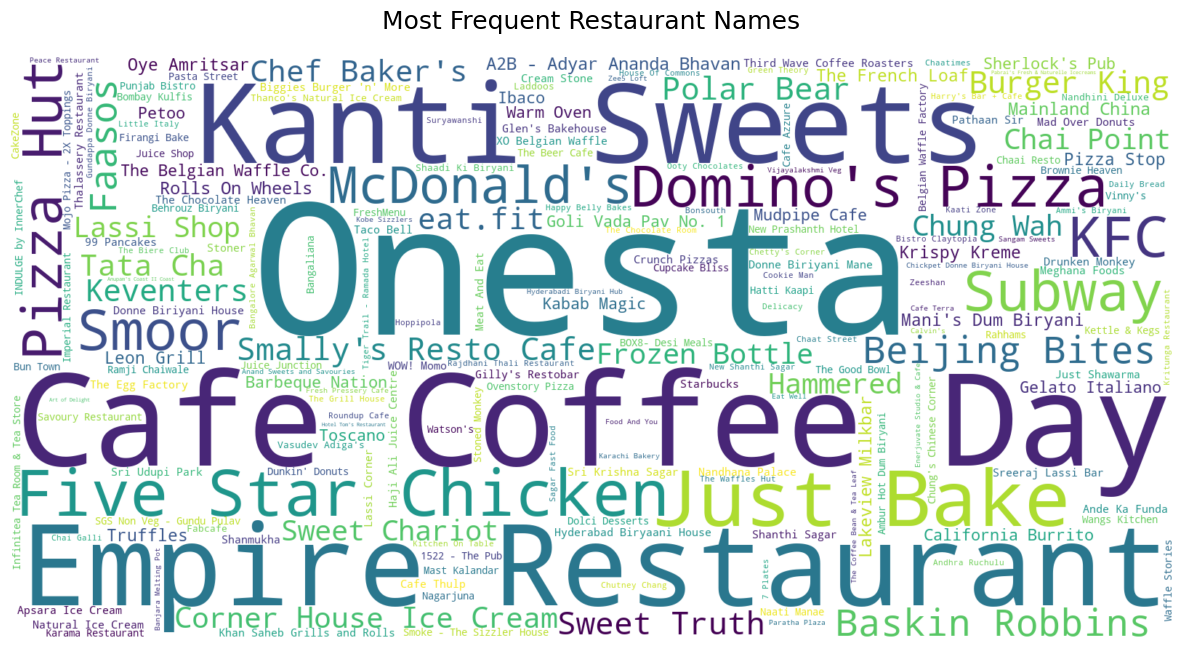

In [192]:
from wordcloud import WordCloud
## used ChatGPT to beautify the wordcloud plot->
# Generate word cloud from restaurant names
wordcloud = WordCloud(
    width=1600,
    height=800,
    background_color='white',
    colormap='viridis',
    max_words=200,
    relative_scaling=0.5
).generate_from_frequencies(df['name'].value_counts())

# Display the word cloud
plt.figure(figsize=(15, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Most Frequent Restaurant Names", fontsize=18, pad=20)
plt.show("Most Frequent Restaurant Names.png")


- Onesta and Cafe Coffee Day, salute 🫡

In [200]:
df.approx_cost = df['approx_cost'].astype('str')
df['approx_cost'] = df['approx_cost'].str.replace(',', '').str.replace(' ', '')
df.approx_cost.value_counts()

approx_cost
400     4715
300     4500
500     3637
600     2889
200     2724
        ... 
120        2
70         1
5000       1
3700       1
80         1
Name: count, Length: 63, dtype: int64

In [202]:
df['approx_cost'].isnull().sum()

np.int64(0)

In [203]:

df.approx_cost = df.approx_cost.astype('int')

/var/folders/49/z4dsjwnj3bz30nknl9ffld4h0000gn/T/ipykernel_23463/1324079509.py:3: FutureWarning:



The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.



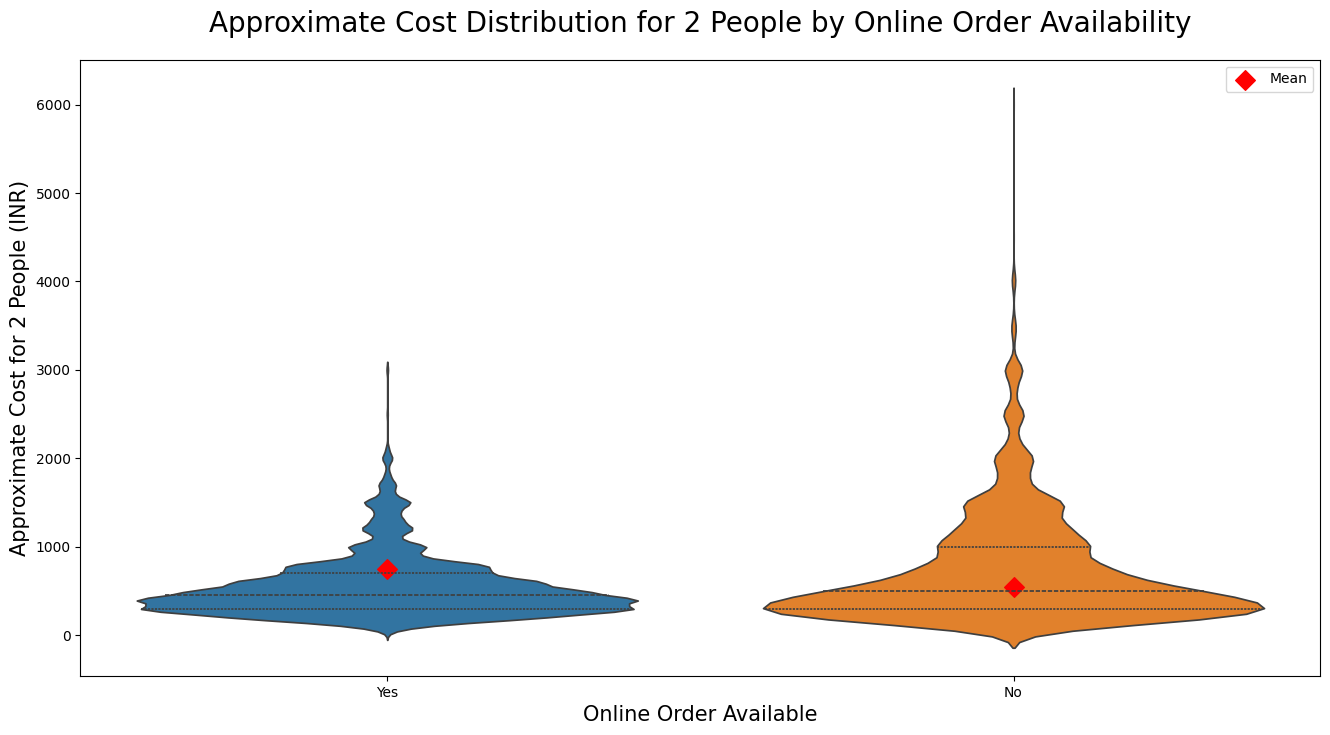

In [204]:
plt.figure(figsize=(16,8))

sns.violinplot(
    x='online_order',
    y='approx_cost',
    hue='online_order',
    data=df,
    palette={'Yes':'#1f77b4', 'No':'#ff7f0e'},
    inner='quartile',    # shows median and quartiles
    scale='width',
    legend=False
)

# Plot mean for each category
means = df.groupby('online_order')['approx_cost'].mean()
for i, val in enumerate(means):
    plt.scatter(i, val, color='red', s=100, marker='D', label='Mean' if i==0 else "")

plt.title('Approximate Cost Distribution for 2 People by Online Order Availability', fontsize=20, pad=20)
plt.xlabel('Online Order Available', fontsize=15)
plt.ylabel('Approximate Cost for 2 People (INR)', fontsize=15)
plt.legend()
plt.show("approx_cost_violinplot2")


/var/folders/49/z4dsjwnj3bz30nknl9ffld4h0000gn/T/ipykernel_23463/988911243.py:5: FutureWarning:



The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.



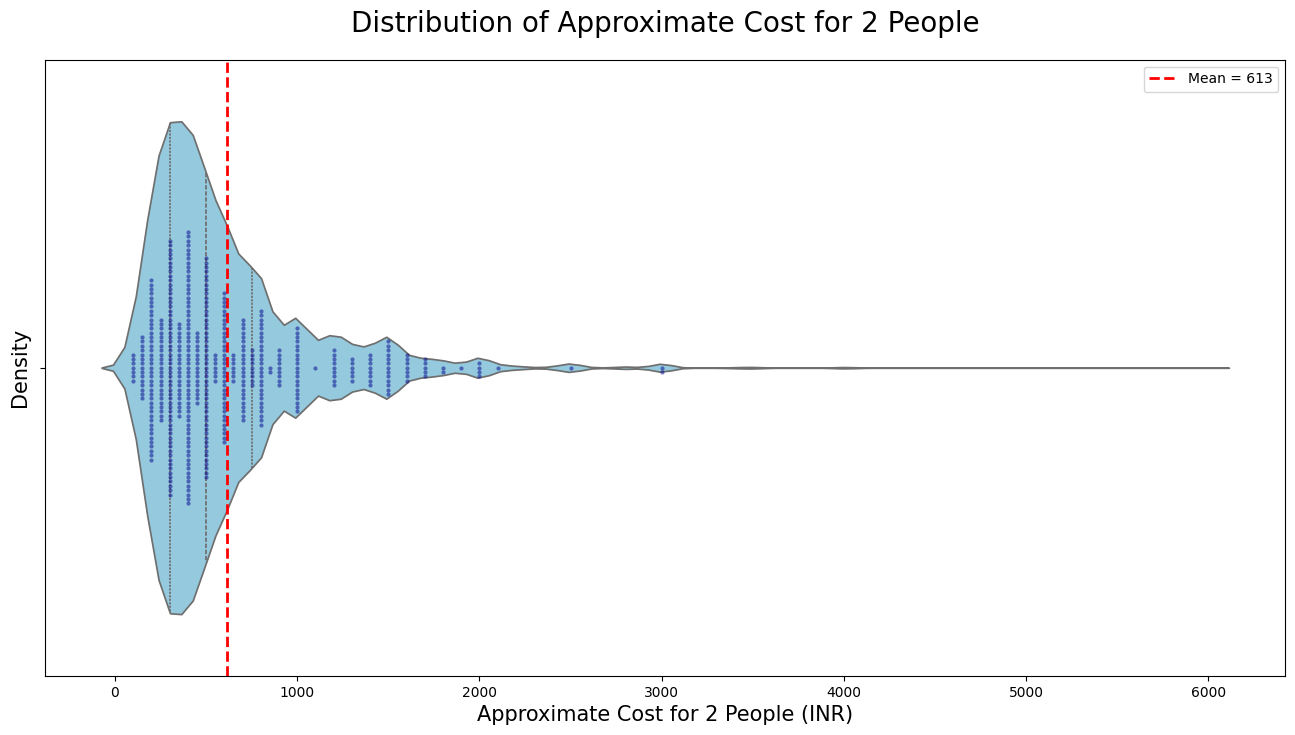

In [205]:
## Violin plot for approx_cost
# used ChatGPT to beautify the violin plot->

plt.figure(figsize=(16,8))
sns.violinplot(
    x=df['approx_cost'],
    color='skyblue',
    inner='quartile',
    scale='width'
)
sns.swarmplot(
    x=df['approx_cost'].sample(500, random_state=42),  # only plot 500 points
    color='darkblue',
    size=3,
    alpha=0.5
)
mean_cost = df['approx_cost'].mean()
plt.axvline(mean_cost, color='red', linestyle='--', linewidth=2, label=f'Mean = {int(mean_cost)}')
plt.title('Distribution of Approximate Cost for 2 People', fontsize=20, pad=20)
plt.xlabel('Approximate Cost for 2 People (INR)', fontsize=15)
plt.ylabel('Density', fontsize=15)
plt.legend()
plt.show("approx_cost_violinplot")


## How does various Features affect Rating of the Restaurant 

### Box Plotting

In [206]:
import matplotlib.pyplot as plt
import seaborn as sns

def box_plot(df, col, plot_name):
    # Sort categories by median rate
    sorted_vals = df.groupby(col)['rate'].median().sort_values()

    # Plot
    plt.figure(figsize=(15, 8))
    sns.boxplot(x=col, y='rate', data=df, order=sorted_vals.index, palette='crest')

    plt.title(f"Distribution of Ratings by {col.capitalize()}", fontsize=16)
    plt.xlabel(col.capitalize(), fontsize=12)
    plt.ylabel("Rating", fontsize=12)
    plt.xticks(rotation=45)
    plt.tight_layout()

    plt.show(plot_name)
    print(f"Boxplot saved as {plot_name}")


In [208]:
df.columns

Index(['name', 'online_order', 'book_table', 'rate', 'votes', 'location',
       'rest_type', 'cuisines', 'approx_cost', 'reviews_list', 'type'],
      dtype='object')

/var/folders/49/z4dsjwnj3bz30nknl9ffld4h0000gn/T/ipykernel_23463/4284245255.py:10: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




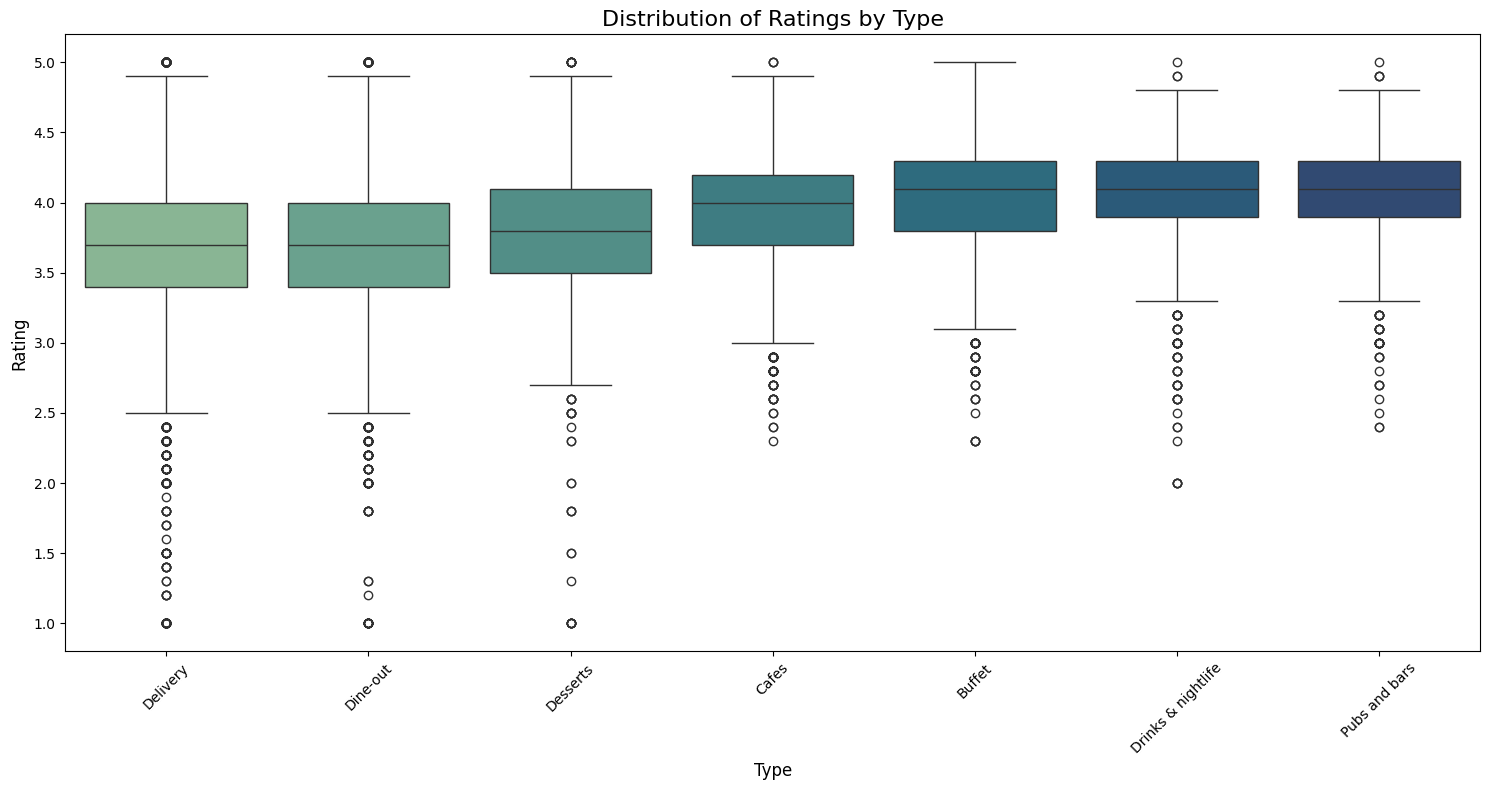

Boxplot saved as type_vs_rating_boxplot


In [209]:
box_plot(df, 'type', "type_vs_rating_boxplot")


In [210]:
df.columns

Index(['name', 'online_order', 'book_table', 'rate', 'votes', 'location',
       'rest_type', 'cuisines', 'approx_cost', 'reviews_list', 'type'],
      dtype='object')

- bookingg vs restaurant rating 

/var/folders/49/z4dsjwnj3bz30nknl9ffld4h0000gn/T/ipykernel_23463/4284245255.py:10: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




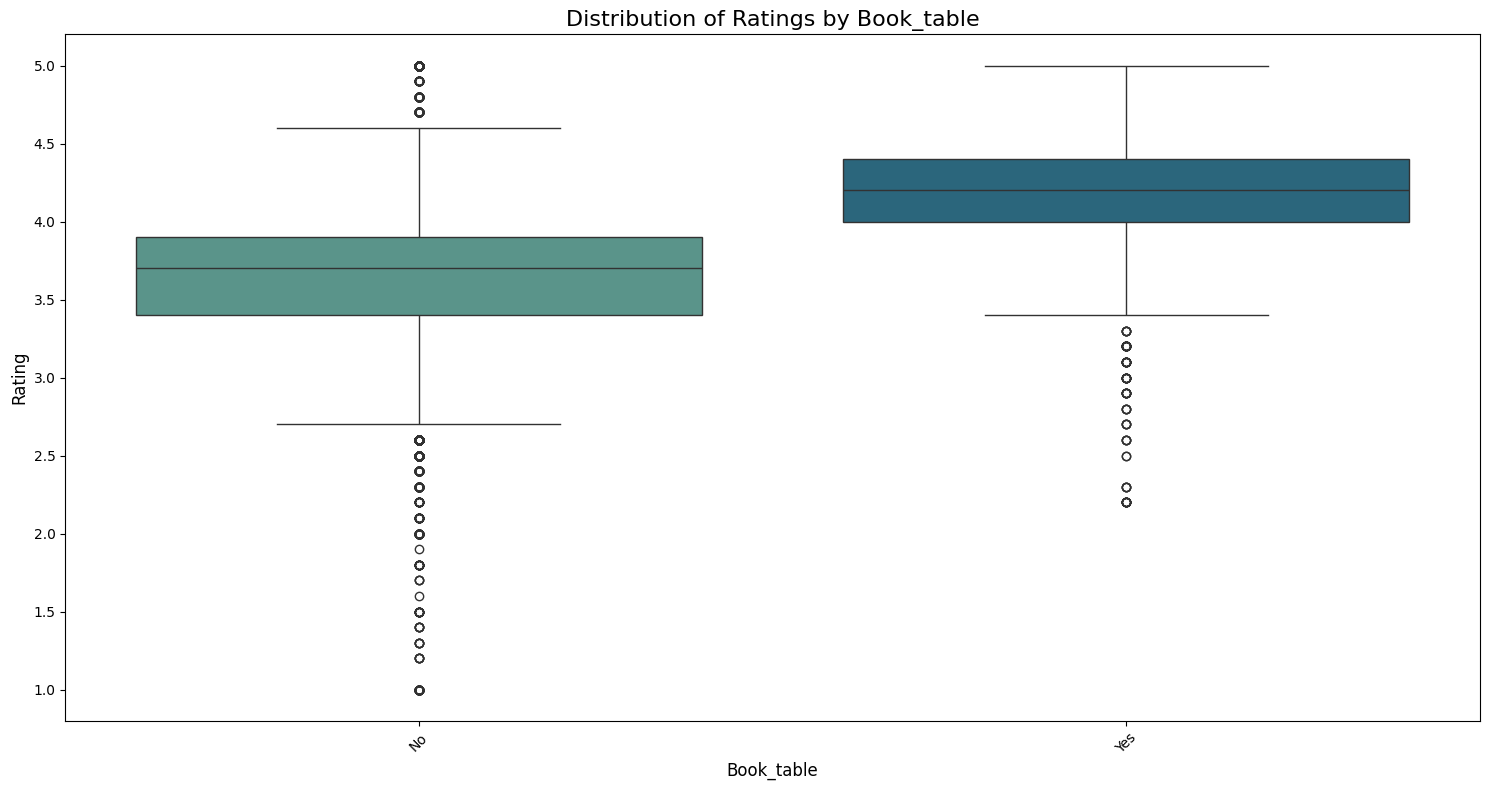

Boxplot saved as booking_vs_rating_boxplot


In [211]:
box_plot(df, 'book_table', plot_name='booking_vs_rating_boxplot')


#### finding->
- Higher Rating leads to Higher Table booking

Restaurant Type vs Rating BoxPlot

### Finding->
- "pubs and bars" restuarants  and "Drinks & nightlife" restaurants have usually higher rating

/var/folders/49/z4dsjwnj3bz30nknl9ffld4h0000gn/T/ipykernel_23463/4284245255.py:10: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




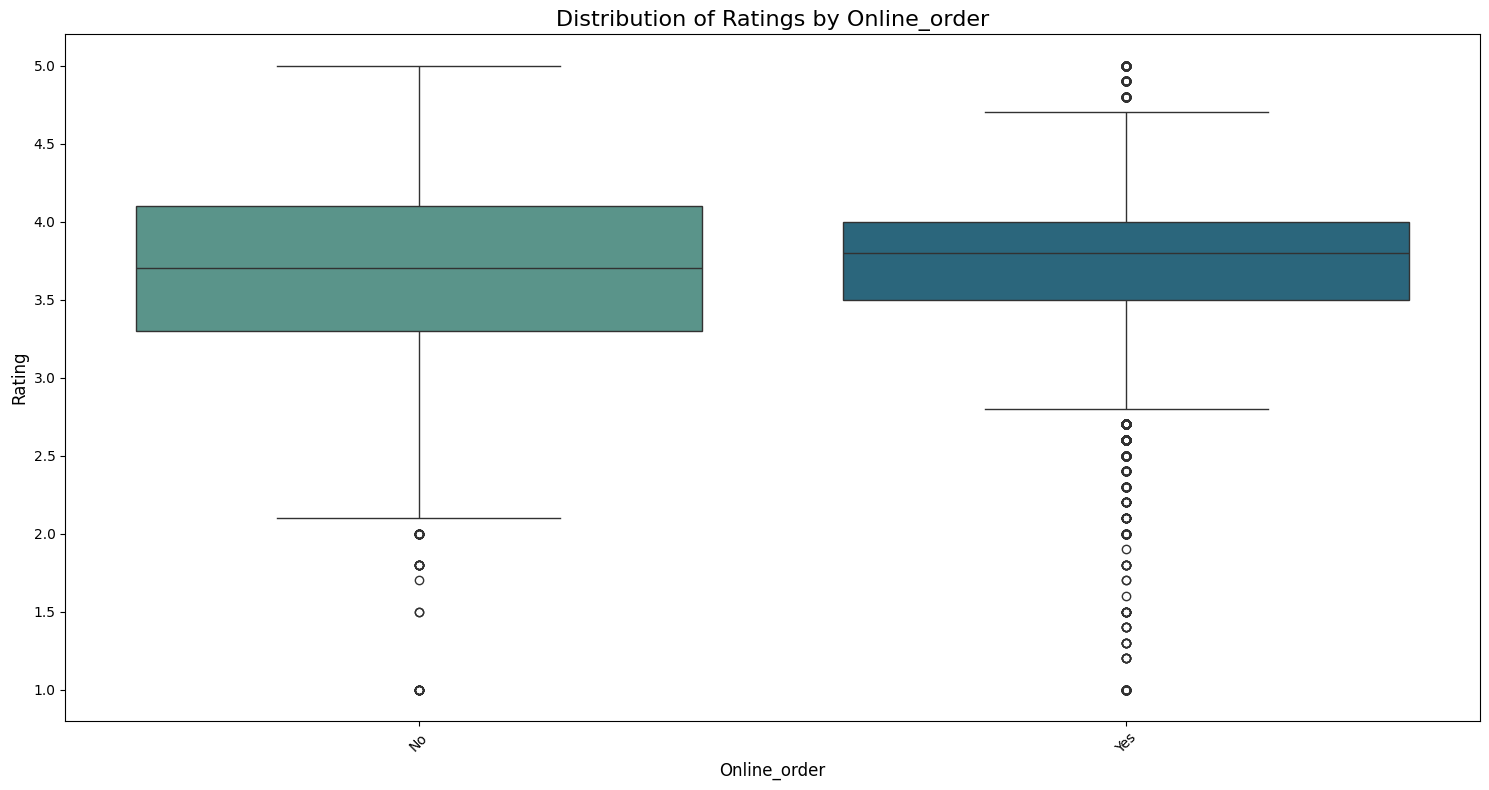

Boxplot saved as online_order_vs_rating_boxplot


In [213]:
box_plot(df, 'online_order', "online_order_vs_rating_boxplot")

### Hist Plots

- Does Rating affect Online Order Quantity?

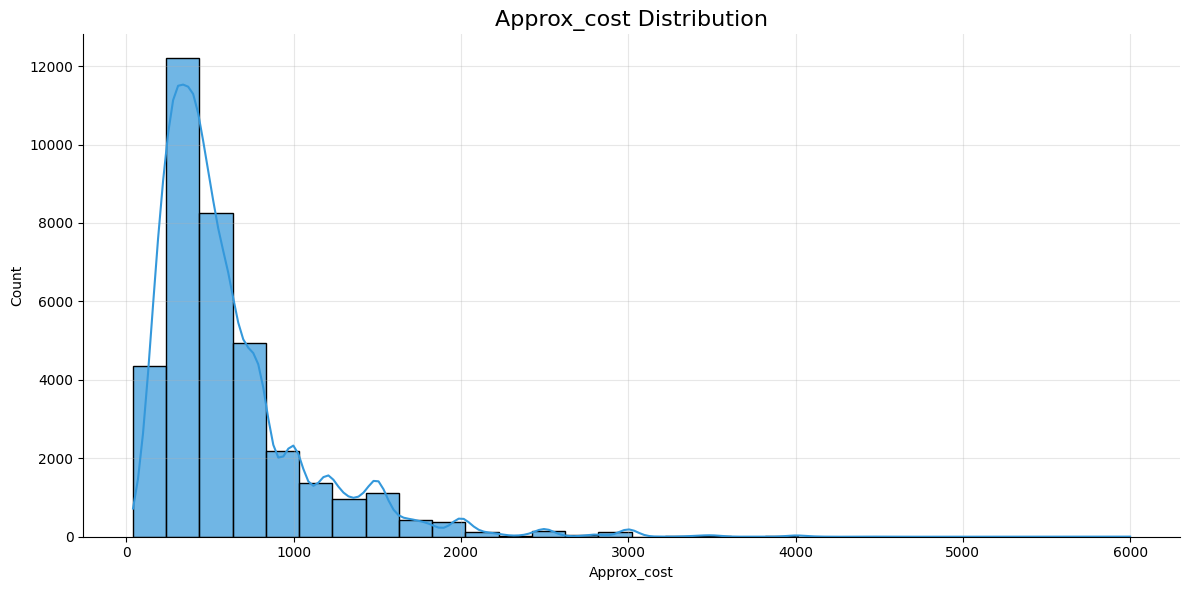

Histogram saved as approx_cost_histogram


In [214]:
## defining hist_plot function
## used ChatGPT to beautify the hist_plot function->
def hist_plot(df, col, plot_name=None, bins=10):
    """
    histogram with KDE for any numeric column.
    """
    # Clean numeric data
    data = pd.to_numeric(df[col], errors='coerce').dropna()
    # Plot
    plt.figure(figsize=(12,6))
    sns.histplot(data, bins=bins, kde=True, color="#3498db", edgecolor='black', alpha=0.7)

    plt.title(f"{col.capitalize()} Distribution", fontsize=16)
    plt.xlabel(col.capitalize())
    plt.ylabel("Count")
    sns.despine()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show(plot_name)
    print(f"Histogram saved as {plot_name}")

hist_plot(df, 'approx_cost', plot_name='approx_cost_histogram', bins=30)

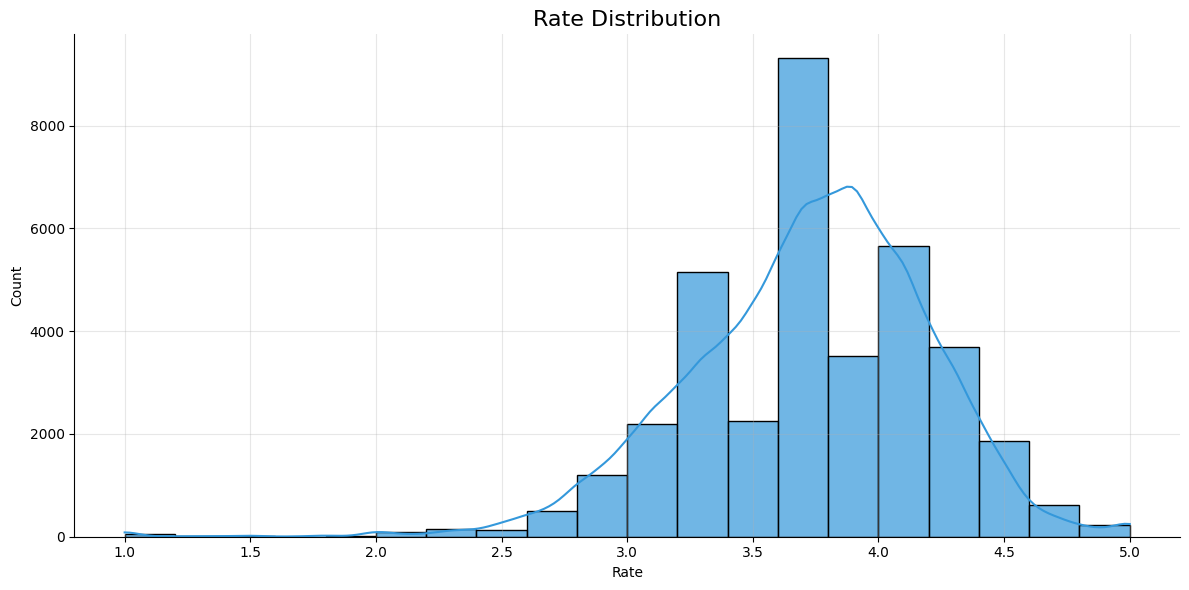

Histogram saved as rate_histogram


In [216]:
hist_plot(df, 'rate', plot_name='rate_histogram', bins=20)

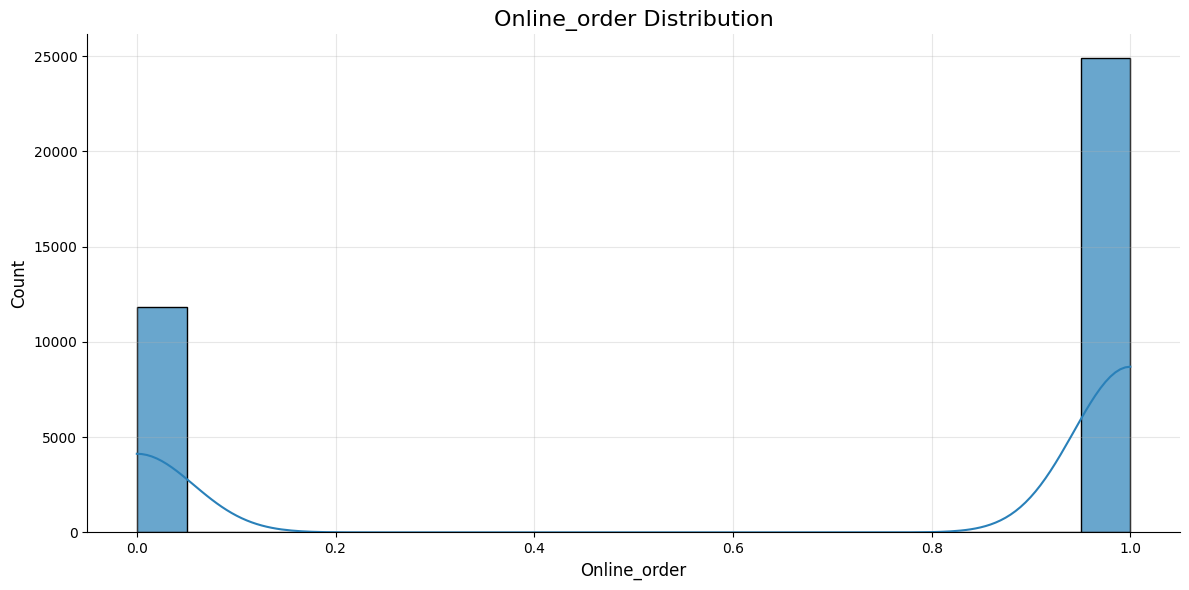

✅ Histogram saved as 'online_order_histogram.png'


In [219]:
## online_order column is categorical with Yes/No values
## modifying hist_plot function to handle Yes/No categorical data
# plotting histogram for online_order  vs rating
def hist_plot(df, col, plot_name=None, bins=15):
    """
    Simple and beautiful histogram for numeric columns.
    Automatically handles Yes/No categorical data.
    """
    # Handle Yes/No categorical case
    if df[col].dtype == 'object':
        if set(df[col].dropna().unique()) == {'Yes', 'No'}:
            df = df.copy()
            df[col] = df[col].map({'Yes': 1, 'No': 0})
        else:
            print(f"⚠️ '{col}' is non-numeric and not a Yes/No column — skipping.")
            return

    # Convert to numeric safely
    data = pd.to_numeric(df[col], errors='coerce').dropna()

    plt.figure(figsize=(12,6))
    sns.histplot(data, bins=bins, kde=True, color="#2980b9", alpha=0.7, edgecolor='black')

    plt.title(f"{col.capitalize()} Distribution", fontsize=16)
    plt.xlabel(col.capitalize(), fontsize=12)
    plt.ylabel("Count", fontsize=12)
    sns.despine()
    plt.grid(alpha=0.3)
    plt.tight_layout()

    if plot_name is None:
        plot_name = f"hist_{col}.png"
    elif not plot_name.endswith(".png"):
        plot_name += ".png"


    plt.show()
    print(f"✅ Histogram saved as '{plot_name}'")

hist_plot(df, 'online_order', plot_name='online_order_histogram', bins=20)


### Finding-> 
- Weird but Restaurants having rating>4.3 have significantly lower online order count than those having rating within 3 to 4.2 
- maybe the restaurants having rating>4.3 might have higher prices or maybe people think they are fake rating(may be)

In [220]:
#df.head(2)

/var/folders/49/z4dsjwnj3bz30nknl9ffld4h0000gn/T/ipykernel_23463/3856075360.py:7: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




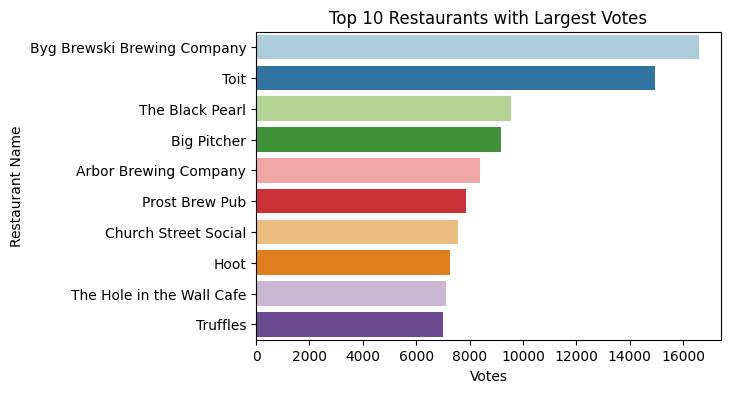

In [222]:
top_votes = df.groupby('name')['votes'].agg(['mean', 'count']).nlargest(10, 'mean')

# Create a figure and axis
fig, ax = plt.subplots(figsize=(6,4))

# Bar plot for top 10 restaurants with largest Votes
bars = sns.barplot(x=top_votes['mean'], y=top_votes.index, palette='Paired', ax=ax)
ax.set(xlabel='Votes', ylabel='Restaurant Name', title='Top 10 Restaurants with Largest Votes')

# Show the plot
plt.show()

Online order data type change before performing analysis

In [225]:
df['online_order'].unique()


array(['Yes', 'No'], dtype=object)

### Convertingg cateory yes/no to 0/1 for our analysis

In [226]:
df['book_table'] = df['book_table'].map({'Yes': 1, 'No': 0})

In [227]:
# Assuming df_clean is your cleaned dataframe
# Step 1: Create rating groups
df['rating_group'] = pd.cut(
    df['rate'],
    bins=[0, 4.2, 5],
    labels=['3 to 4.2', '4.3 and above']
)


df['online_order'] = df['online_order'].map({'Yes': 1, 'No': 0})
# Step 2: Aggregate statistics
group_stats = df.groupby('rating_group').agg({
    'online_order': 'mean',                    # assuming 0/1 for online order
    'approx_cost': 'mean'
}).reset_index()

/var/folders/49/z4dsjwnj3bz30nknl9ffld4h0000gn/T/ipykernel_23463/528765570.py:12: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



/var/folders/49/z4dsjwnj3bz30nknl9ffld4h0000gn/T/ipykernel_23463/590749209.py:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




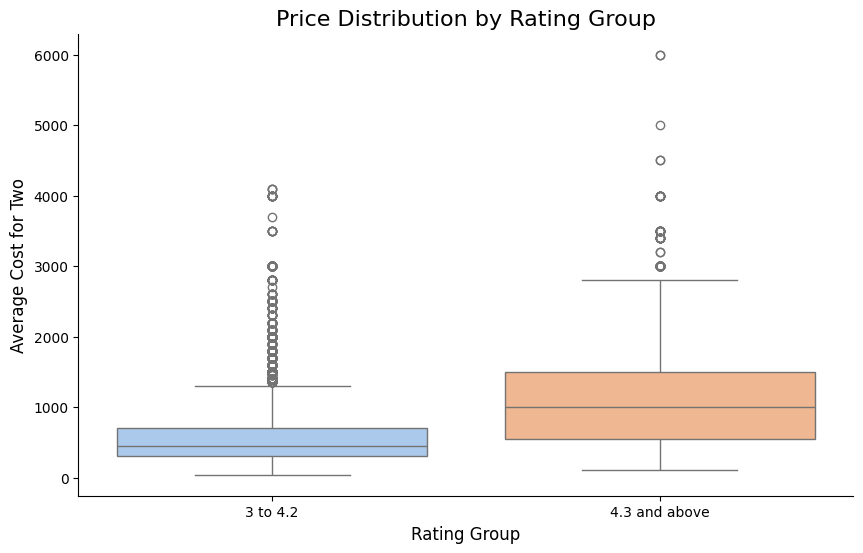

/var/folders/49/z4dsjwnj3bz30nknl9ffld4h0000gn/T/ipykernel_23463/590749209.py:17: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




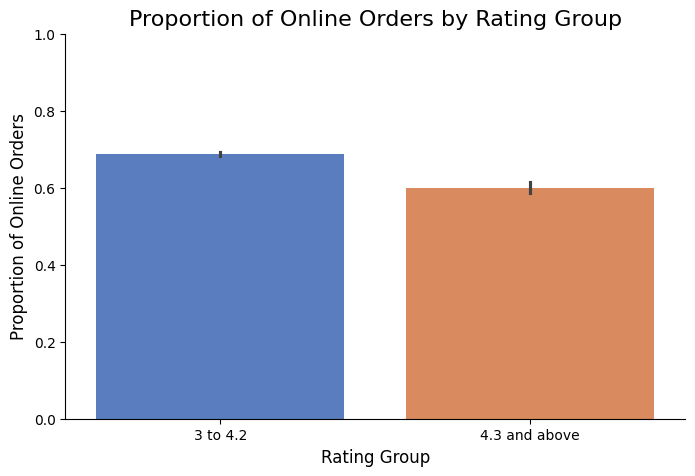

/var/folders/49/z4dsjwnj3bz30nknl9ffld4h0000gn/T/ipykernel_23463/590749209.py:30: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




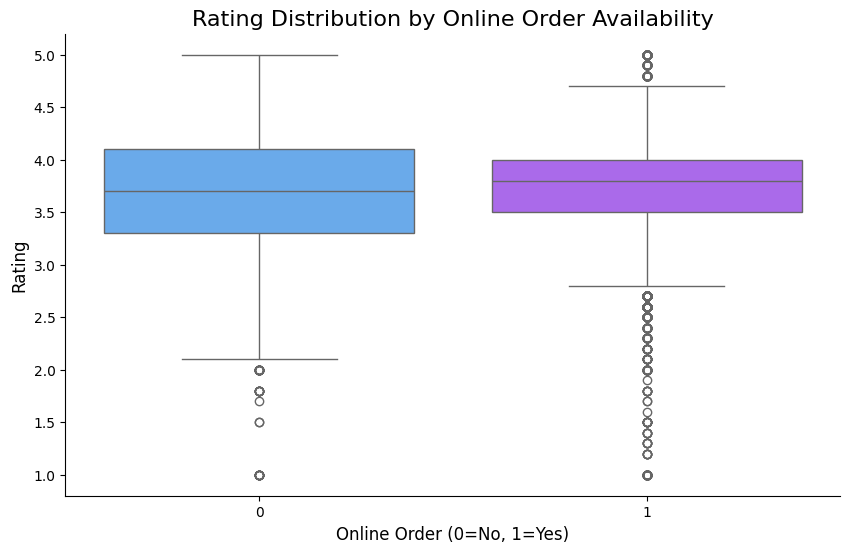

In [228]:
## Trying to find the reason behind the online order count variation with respect to rating
## Finding->
## code logic-chatGPT+ me
# Step: Visualize average cost by rating group
plt.figure(figsize=(10,6))
sns.boxplot(x='rating_group', y='approx_cost', data=df, palette='pastel')
plt.title("Price Distribution by Rating Group", fontsize=16)
plt.xlabel("Rating Group", fontsize=12)
plt.ylabel("Average Cost for Two", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
sns.despine()
plt.show()

# Step: Visualize online order proportion by rating group
plt.figure(figsize=(8,5))
sns.barplot(x='rating_group', y='online_order', data=df, palette='muted')
plt.title("Proportion of Online Orders by Rating Group", fontsize=16)
plt.xlabel("Rating Group", fontsize=12)
plt.ylabel("Proportion of Online Orders", fontsize=12)
plt.ylim(0,1)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
sns.despine()
plt.show()


# Step: Optional: Boxplot of ratings vs online order availability
plt.figure(figsize=(10,6))
sns.boxplot(x='online_order', y='rate', data=df, palette='cool')
plt.title("Rating Distribution by Online Order Availability", fontsize=16)
plt.xlabel("Online Order (0=No, 1=Yes)", fontsize=12)
plt.ylabel("Rating", fontsize=12)
sns.despine()
plt.show()


In [229]:
df.head(1)

,name,online_order,book_table,rate,votes,location,rest_type,cuisines,approx_cost,reviews_list,type,rating_group
0,Jalsa,1,1,4.1,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800,"[(Rated 4.0, RATED\n A beautiful place to din...",Buffet,3 to 4.2


## continue from here-> 

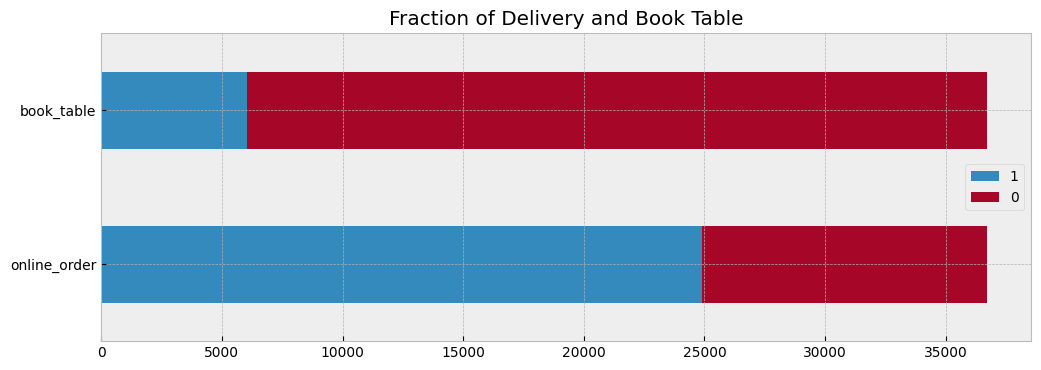

In [230]:
with plt.style.context('bmh', after_reset = True):
    plt.figure(figsize = (12,4))
    ax = plt.subplot(1,1,1)
    tmp = {}
    for col in ['online_order', 'book_table']: 
        tmp[col] = df[col].value_counts()
    tmp = pd.DataFrame.from_dict(tmp, orient = 'index')
    tmp.plot.barh(stacked = True, ax = ax)
    ax.set_title('Fraction of Delivery and Book Table')
    plt.show("delivery_booktable_fraction")

## Map 

### Getting coordinates from location column

- 🛑 this code might take a bit longer to execute as this goes through every address and searches for it and then gets the coordinates accordingly

In [231]:
## Zomato Presence across Bangalore
# used chatGPT to debug


## coordinates of Bangalore->
from geopy.geocoders import Nominatim # ''' Nominatim is a free geocoding service from OpenStreetMap — it converts human-readable locations (like “Koramangala, Bengaluru”) into latitude and longitude coordinates. '''
location = [x for x in df['location'].unique().tolist() if type(x) == str]
latitude = []
longitude =  []
for i in range(0, len(location)):
    if(type(location[i]) == str):
        ctr=0
        while True:
            try:
                address = location[i] + ', Bengaluru, India'
                geolocator = Nominatim(user_agent="ny_explorer") #This is the actual API call to OpenStreetMap’s Nominatim service.
                '''It searches for “Indiranagar, Bengaluru, India” If found, it returns a location object with: numerical latitude and longitude coordinates.'''
                loc = geolocator.geocode(address)
                latitude.append(loc.latitude)
                longitude.append(loc.longitude)
                print('The geograpical coordinate of location are {}, {}.'.format(loc.latitude, loc.longitude))
            except:
                ctr+=1
                if(ctr==7):
                    print(i)
                    latitude.append(address)
                    longitude.append(address)
                    break
                continue
            break



The geograpical coordinate of location are 12.9278196, 77.556621.
The geograpical coordinate of location are 12.9417261, 77.5755021.
The geograpical coordinate of location are 12.9467026, 77.5300705.
The geograpical coordinate of location are 12.9292731, 77.5824229.
The geograpical coordinate of location are 12.9067683, 77.5595021.
The geograpical coordinate of location are 12.9274413, 77.5155224.
The geograpical coordinate of location are 12.9660726, 77.6125941.
The geograpical coordinate of location are 12.9055682, 77.5455438.
The geograpical coordinate of location are 12.9096941, 77.5866067.
The geograpical coordinate of location are 12.9287596, 77.6287122.
The geograpical coordinate of location are 12.965718, 77.5762705.
The geograpical coordinate of location are 12.8580356, 77.5889558.
The geograpical coordinate of location are 12.9112759, 77.6045654.
The geograpical coordinate of location are 12.8712415, 77.5385451.
The geograpical coordinate of location are 12.9089453, 77.623903

### Getting coordinated from the location column

In [232]:
df['location_latitude'] = df['location'].map(dict(zip(location, latitude)))
df['location_longitude'] = df['location'].map(dict(zip(location, longitude)))

In [233]:
for lat in df['location_latitude'].unique():
    if type(lat) == str:
        df = df[df['location_latitude'] != lat]

for lng in df['location_longitude'].unique():
    if type(lng) == str:
        df = df[df['location_longitude'] != lng]
df['location_latitude'] = df['location_latitude'].astype(float)
df['location_longitude'] = df['location_longitude'].astype(float)

In [234]:
df['location_latitude'].unique()

array([12.9278196, 12.9417261, 12.9467026, 12.9292731, 12.9067683,
       12.9274413, 12.9660726, 12.9055682, 12.9096941, 12.9287596,
       12.965718 , 12.8580356, 12.9112759, 12.8712415, 12.9089453,
       12.8487599, 12.9489339, 12.9555367, 12.9348429, 12.9657678,
       12.9116225, 12.9364846, 12.9371445, 12.9244884, 12.9552572,
       12.9963995, 12.9722154, 12.9582766, 12.9732913, 12.9277245,
       12.9975851, 12.9755264, 12.9736441, 12.9712421, 12.9746938,
       12.9778793, 12.9692682, 12.9855286, 12.982005 , 12.9728057,
       12.9884255, 12.9835482, 12.9822423, 12.9921738, 12.9624669,
       12.9408685, 12.945245 , 12.9678074, 13.0082277, 12.9931876,
       13.0148544, 12.9390255, 12.9779079, 12.957998 , 12.9730087,
       12.9652094, 12.9625188, 12.9243692, 12.9282918, 12.9327778,
       12.9357366, 12.9553319, 13.0227204, 13.0141618, 13.0222347,
       13.0422794, 13.037077 , 13.0221416, 13.031992 , 12.973936 ,
       12.9850987, 12.9819618, 12.9176571, 12.9967842, 13.0027

In [236]:
df.groupby(['location'])['rate'].mean().sort_values()[-50:][:-1]

location
Rajajinagar              3.623095
Whitefield               3.623277
Vijay Nagar              3.623438
Old Airport Road         3.627606
Brookefield              3.627839
Sahakara Nagar           3.633333
Frazer Town              3.634809
Basaveshwara Nagar       3.654545
Mysore Road              3.656250
Banashankari             3.669677
Kammanahalli             3.675289
HBR Layout               3.679348
Basavanagudi             3.693200
Sarjapur Road            3.695967
New BEL Road             3.696421
Yelahanka                3.700000
HSR                      3.706556
JP Nagar                 3.709505
Kengeri                  3.716667
Commercial Street        3.720488
Vasanth Nagar            3.727604
Koramangala 1st Block    3.730117
Brigade Road             3.734217
Langford Town            3.752941
Seshadripuram            3.758268
Ulsoor                   3.769521
West Bangalore           3.775000
Koramangala 2nd Block    3.780000
Malleshwaram             3.782683
Koram

In [239]:
df.columns

Index(['name', 'online_order', 'book_table', 'rate', 'votes', 'location',
       'rest_type', 'cuisines', 'approx_cost', 'reviews_list', 'type',
       'rating_group', 'location_latitude', 'location_longitude'],
      dtype='object')

In [240]:
## Map of Zomato's restaurant locations in Bangalore
# Create a map centered around Bangalore

dataframe_filtered = df.groupby(['location'])[['location_latitude', 'location_longitude']].first()
dataframe_filtered['no_restaurant'] = df.groupby(['location'])['name'].count()
venues_map = folium.Map(location=[12.934533, 77.626579], zoom_start=11) # generate map centred around Bengaluru

states = folium.map.FeatureGroup()
i=0
for lat, lng, in zip(dataframe_filtered.location_latitude, dataframe_filtered.location_longitude):
    states.add_child(
        folium.features.CircleMarker(
            [lat, lng],
            radius=5, # define how big you want the circle markers to be
            color='yellow',
            fill=True,
            fill_color='blue',
            fill_opacity=0.6,
        )
    )
    i+=1
i=0
for lat, lng, in zip(dataframe_filtered.location_latitude, dataframe_filtered.location_longitude):
    states.add_child(
        folium.features.Marker(
            [lat, lng],
            popup= dataframe_filtered.index[i],
        )
    )
    i+=1
# add incidents to map
venues_map.add_child(states)
venues_map

In [241]:
print(df.columns)


Index(['name', 'online_order', 'book_table', 'rate', 'votes', 'location',
       'rest_type', 'cuisines', 'approx_cost', 'reviews_list', 'type',
       'rating_group', 'location_latitude', 'location_longitude'],
      dtype='object')


### (Map) Bubble based on the number of Restaurants 

In [243]:
df.head(2)

,name,online_order,book_table,rate,votes,location,rest_type,cuisines,approx_cost,reviews_list,type,rating_group,location_latitude,location_longitude
0,Jalsa,1,1,4.1,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800,"[(Rated 4.0, RATED\n A beautiful place to din...",Buffet,3 to 4.2,12.92782,77.556621
1,Spice Elephant,1,0,4.1,787,Banashankari,Casual Dining,"Chinese, North Indian, Thai",800,"[(Rated 4.0, RATED\n Had been here for dinner...",Buffet,3 to 4.2,12.92782,77.556621


In [244]:
import folium

# ✅ Group by 'location' and count how many restaurants per location
dataframe_filtered = (
    df.groupby('location')
      .agg({
          'location_latitude': 'first',
          'location_longitude': 'first',
          'name': 'count'  # count restaurants instead of 'url'
      })
      .rename(columns={'name': 'no_restaurant'})
      .reset_index()
)

# ✅ Create map centered on Bangalore
venues_map = folium.Map(location=[12.9716, 77.5946], zoom_start=11)

# ✅ Add circle markers
for idx, row in dataframe_filtered.iterrows():
    folium.CircleMarker(
        location=[float(row['location_latitude']), float(row['location_longitude'])],
        radius=5 + row['no_restaurant'] * 0.01,  # bubble size based on restaurant count
        color='blue',
        fill=True,
        fill_color='lightblue',
        fill_opacity=0.6,
        popup=f"{row['location']} — {row['no_restaurant']} restaurants"
    ).add_to(venues_map)

# ✅ Save and display
venues_map.save("bangalore_restaurants_map.html")
print("✅ Map saved as 'bangalore_restaurants_map.html'")

venues_map



✅ Map saved as 'bangalore_restaurants_map.html'


In [245]:
## trying to Clean Cuisine column for better analysis
columns = ['cuisine', 'Total Restaurants', 'rate']
df_cuisine = pd.DataFrame(columns = columns) 

# creating a dataframe to store cuisine, total restaurants having that cuisine and average rate of that cuisine

for cuisine in df['cuisines'].unique():
    # DataFrame' object has no attribute 'append' (got to know from Error message🙂)
    df_cuisine = pd.concat([df_cuisine, pd.DataFrame({'cuisine': [cuisine],
                                                       'Total Restaurants': [df[df['cuisines'] == cuisine].shape[0]],
                                                       'rate': [df[df['cuisines'] == cuisine]['rate'].mean()]})], ignore_index=True)

/var/folders/49/z4dsjwnj3bz30nknl9ffld4h0000gn/T/ipykernel_23463/3671295783.py:9: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.



In [248]:
df_cuisine.head(6) # done

,cuisine,Total Restaurants,rate
0,"North Indian, Mughlai, Chinese",90,3.372222
1,"Chinese, North Indian, Thai",8,3.750000
2,"Cafe, Mexican, Italian",10,3.800000
3,"South Indian, North Indian",184,3.577174
4,"North Indian, Rajasthani",6,3.900000
5,North Indian,1880,3.603670


### Let us ifnd the cuisines that has averae rating of >4. -> (Personal Curiosity)

In [250]:
df_cuisine[df_cuisine['rate'] > 4].head(10).sort_values(by='rate', ascending=False) # also sorted by rate

,cuisine,Total Restaurants,rate
7,"Pizza, Cafe, Italian",85,4.410588
9,"Cafe, Mexican, Italian, Momos, Beverages",6,4.200000
48,"Asian, Korean, Indonesian, Japanese, Chinese, ...",6,4.200000
51,"Italian, North Indian, Mexican",6,4.133333
15,"Cafe, Italian, American",15,4.126667
56,"Continental, Italian, Mexican, North Indian, C...",3,4.100000
32,"North Indian, Mughlai, South Indian, Chinese",56,4.094643
50,"Desserts, Beverages",232,4.081034
8,"Cafe, Italian, Continental",34,4.058824
37,"North Indian, Continental, Italian",33,4.012121


- Pizza, Cafe, Italian, Mexican, Momos, North Indian etc are the top cuisines

In [251]:
df_cuisine[df_cuisine['rate'] > 4].head(10).sort_values(by='Total Restaurants', ascending=False) # also sorted by rate

,cuisine,Total Restaurants,rate
50,"Desserts, Beverages",232,4.081034
7,"Pizza, Cafe, Italian",85,4.410588
32,"North Indian, Mughlai, South Indian, Chinese",56,4.094643
8,"Cafe, Italian, Continental",34,4.058824
37,"North Indian, Continental, Italian",33,4.012121
15,"Cafe, Italian, American",15,4.126667
9,"Cafe, Mexican, Italian, Momos, Beverages",6,4.200000
48,"Asian, Korean, Indonesian, Japanese, Chinese, ...",6,4.200000
51,"Italian, North Indian, Mexican",6,4.133333
56,"Continental, Italian, Mexican, North Indian, C...",3,4.100000


- Desserts, Beverages cuisines has highest number of restaurants in Bengaluru.
- 247 restaurants!!

In [252]:
df_cuisine['Total Restaurants'].sum()

36545

/var/folders/49/z4dsjwnj3bz30nknl9ffld4h0000gn/T/ipykernel_23463/2361495990.py:7: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




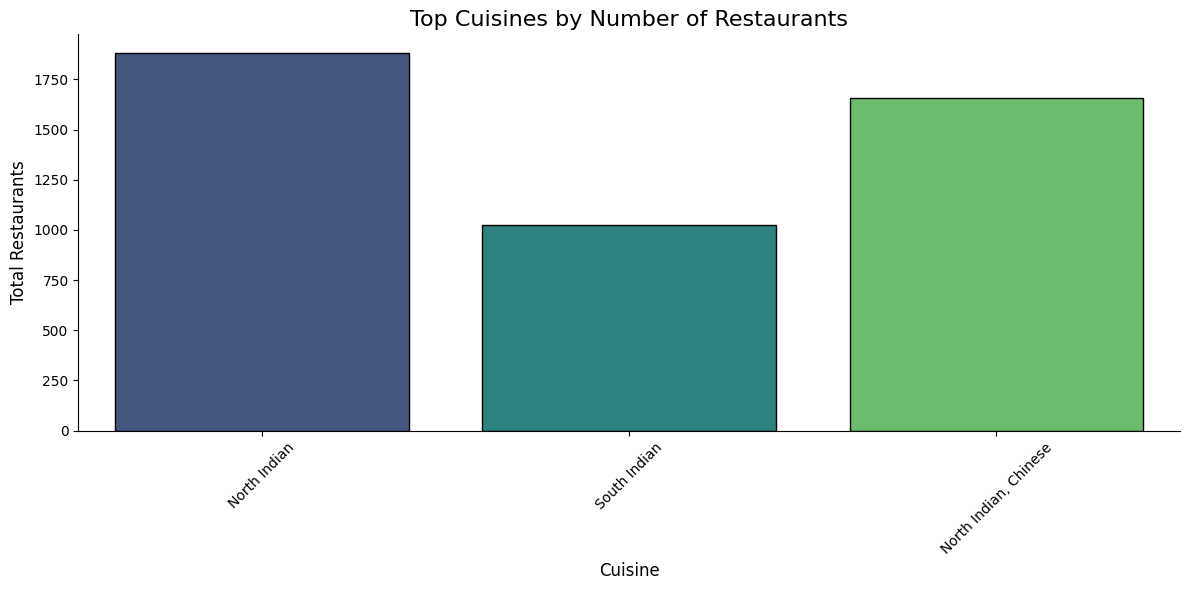

Bar plot saved as top_cuisines


In [253]:
# Filtering & plotting top cuisines
df_cuisine = df_cuisine[df_cuisine['Total Restaurants'] > 900] # Taking cuisines that are atleast served in over 900 restaurants 
# bar plot for top cuisines
# used ChatGPT to beautify the bar plot
def bar_plot(df, x_col, y_col, plot_name):
    plt.figure(figsize=(12,6))
    sns.barplot(x=x_col, y=y_col, data=df, palette='viridis', edgecolor='black')
    plt.title("Top Cuisines by Number of Restaurants", fontsize=16)
    plt.xlabel("Cuisine", fontsize=12)
    plt.ylabel("Total Restaurants", fontsize=12)
    plt.xticks(rotation=45)
    sns.despine()
    plt.tight_layout()
    plt.show(plot_name)
    print(f"Bar plot saved as {plot_name}")
bar_plot(df_cuisine, "cuisine", "Total Restaurants", "top_cuisines")

In [254]:
## polar plot for cuisines vs rating->
# used ChatGPT to beautify the polar plot->
def polar_plot(df, category_col, value_col, plot_name):
    plt.figure(figsize=(10,10))
    ax = plt.subplot(111, polar=True)
    
    # Number of categories
    num_vars = len(df[category_col])
    
    # Compute angle for each category
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    
    # The values to plot
    values = df[value_col].tolist()
    values += values[:1]  # Complete the loop
    
    angles += angles[:1]  # Complete the loop
    
    # Plot data
    ax.fill(angles, values, color='teal', alpha=0.25)
    ax.plot(angles, values, color='teal', linewidth=2)
    
    # Add category labels
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(df[category_col], fontsize=12)
    
    # Add title and labels
    plt.title(f"{value_col.capitalize()} by {category_col.capitalize()}", size=16, y=1.1)
    
    plt.tight_layout()
    plt.show(plot_name)
    print(f"Polar plot saved as {plot_name}")

✅ Auto-saved: visualizations/cuisine_vs_rating_polar_plot.png


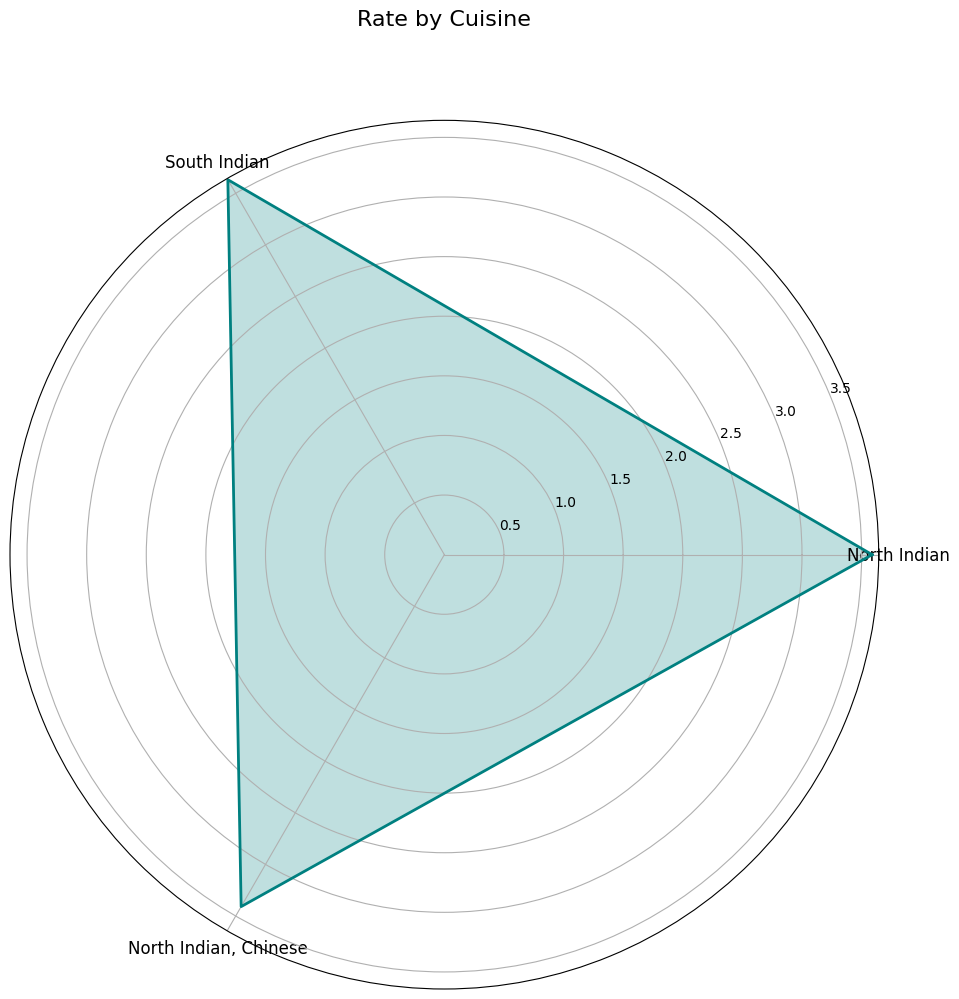

Polar plot saved as cuisine_vs_rating_polar_plot


In [ ]:
polar_plot(df_cuisine, 'cuisine', 'rate', 'cuisine_vs_rating_polar_plot')

### North Indian, South Indian, Chinese cuisines dominate over entire Bengalore!

In [255]:
## savingg new cleaned dataframe
import joblib
joblib.dump(df.reset_index(drop=True), "/Users/mac/Desktop/Desktop_Files/Projects/Zomato Restaurant Rating Prediction/artifacts/EDA_cleaned.pkl") # I've saved the cleaned dataframe after EDA for future use

['/Users/mac/Desktop/Desktop_Files/Projects/Zomato Restaurant Rating Prediction/artifacts/EDA_cleaned.pkl']

### More Cuisines Analysis

Grouping the neighborhood by the cuisines
Is there any neighborhood that is more famous for its cuisines

In [256]:
types = set()
def func(x):
    if(type(x) == list):
        for y in x:
            types.add(y.strip())
_ = df['cuisines'].str.split(',').apply(func)

In [257]:
column_names = list(types)
# instantiate the dataframe
neighborhood_cns = pd.DataFrame(columns=column_names)
neighborhood_cns

,Jewish,Coffee,Spanish,Juices,French,Chinese,BBQ,Singaporean,South American,Hot dogs,...,Iranian,Bihari,Belgian,Bengali,Russian,European,Street Food,Sushi,Turkish,Mediterranean


In [258]:
neighborhood_cns['neighborhood'] = df.groupby('location').groups.keys()
neighborhood_cns = neighborhood_cns.set_index('neighborhood').fillna(0)
neighborhood_cns

/var/folders/49/z4dsjwnj3bz30nknl9ffld4h0000gn/T/ipykernel_23463/330194574.py:2: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



,Jewish,Coffee,Spanish,Juices,French,Chinese,BBQ,Singaporean,South American,Hot dogs,...,Iranian,Bihari,Belgian,Bengali,Russian,European,Street Food,Sushi,Turkish,Mediterranean
neighborhood,,,,,,,,,,,,,,,,,,,,,
BTM,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Banashankari,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Banaswadi,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Bannerghatta Road,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Basavanagudi,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
West Bangalore,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Whitefield,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Wilson Garden,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [259]:
from sklearn.preprocessing import MultiLabelBinarizer
# Split the cuisines by comma and convert to list
df['cuisines_list'] = df['cuisines'].fillna('').apply(lambda x: [c.strip() for c in x.split(',') if c.strip() != ''])

# Initialize MultiLabelBinarizer (chatGPT suggestion for faster one-hot encoding)
mlb = MultiLabelBinarizer()
cuisine_dummies = pd.DataFrame(mlb.fit_transform(df['cuisines_list']),
                               columns=mlb.classes_,
                               index=df.index)

# Group by location and sum the counts
neighborhood_cns = df[['location']].join(cuisine_dummies)
neighborhood_cns = neighborhood_cns.groupby('location').sum()

# Optional: order columns alphabetically (or by your 'types' list if you want)
neighborhood_cns = neighborhood_cns[sorted(neighborhood_cns.columns)]

# Display
print(neighborhood_cns.head())

                   Afghan  Afghani  African  American  Andhra  Arabian  Asian  \
location                                                                        
BTM                    10        0        0        27     126      147     34   
Banashankari            0        0        0         4       9        2      6   
Banaswadi               0        0        0         0      32       10      1   
Bannerghatta Road       0        0        8        30      51       30     12   
Basavanagudi            0        0        0         0      13        0      8   

                   Assamese  Australian  Awadhi  ...  Sushi  Tamil  Tea  \
location                                         ...                      
BTM                       0           0       0  ...      0      0   25   
Banashankari              0           0       0  ...      0      0    3   
Banaswadi                 0           0       0  ...      0      0    0   
Bannerghatta Road         0           0       0  ...     

- Groupingby cuisines by location

### Top 20 Cuisines Of Bengaluru

/var/folders/49/z4dsjwnj3bz30nknl9ffld4h0000gn/T/ipykernel_23463/3764267680.py:11: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




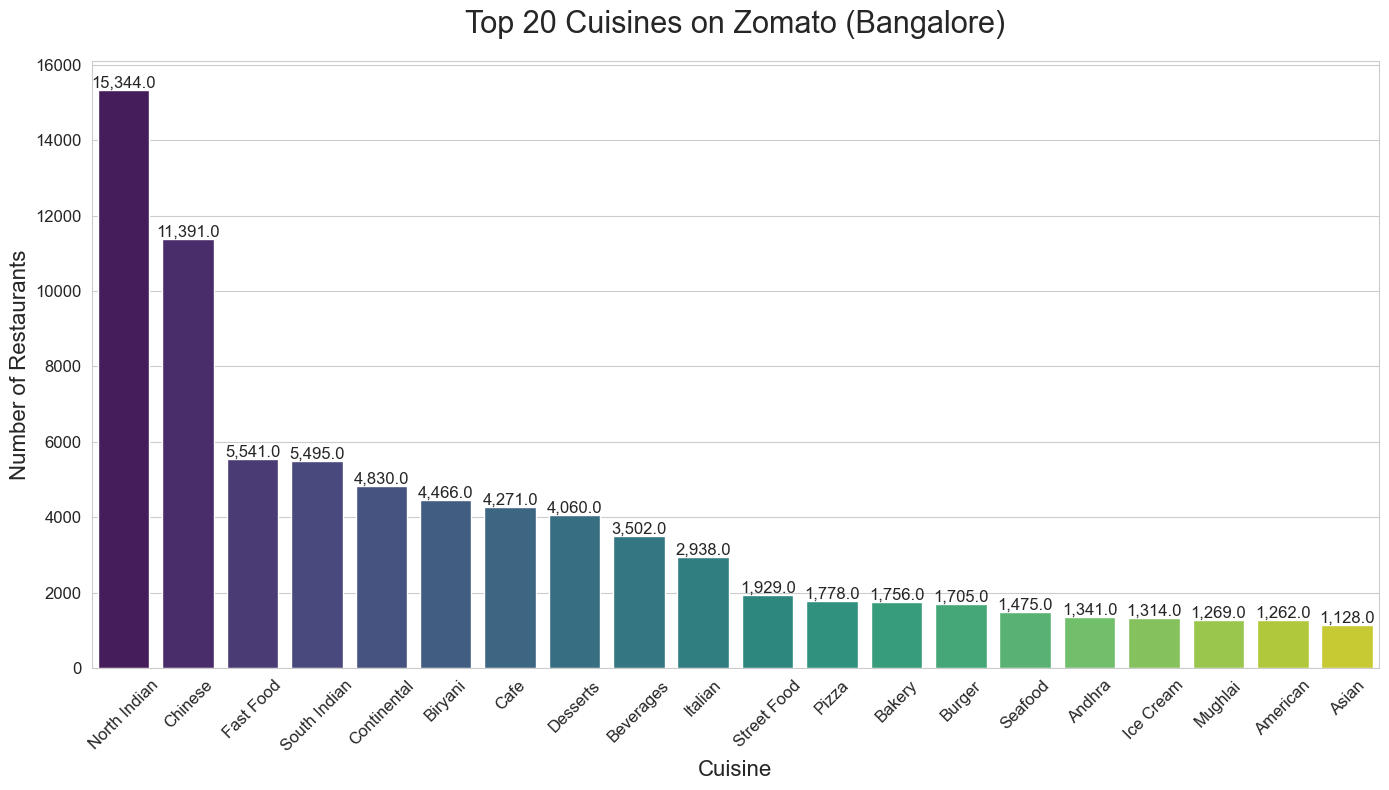

In [ ]:
# Sum the number of restaurants per cuisine
# used chatGPT to beautify the code
Cuisine_data = neighborhood_cns.sum(axis=0).reset_index()
Cuisine_data.columns = ['Cuisine', 'Number_of_Restaurants']

# Get top 20 cuisines
Top20 = Cuisine_data.sort_values(by='Number_of_Restaurants', ascending=False).head(20)

# Plot
sns.set_style("whitegrid")
plt.figure(figsize=(14,8))
barplot = sns.barplot(x='Cuisine', y='Number_of_Restaurants', data=Top20, palette='viridis')

# Add labels on top of bars for clarity
for p in barplot.patches:
    barplot.annotate(format(p.get_height(), ','),
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center',
                     xytext=(0, 5),
                     textcoords='offset points',
                     fontsize=12)

plt.xlabel('Cuisine', fontsize=16)
plt.ylabel('Number of Restaurants', fontsize=16)
plt.title('Top 20 Cuisines on Zomato (Bangalore)', fontsize=22, pad=20)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show("top_20_cuisines")

- Now it makes sense why The Top 3 cuisines here were the same with High Rating, they've largest fan base.

### Top Rated Cuisines of Bengaluru

/var/folders/49/z4dsjwnj3bz30nknl9ffld4h0000gn/T/ipykernel_23463/2096780629.py:14: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




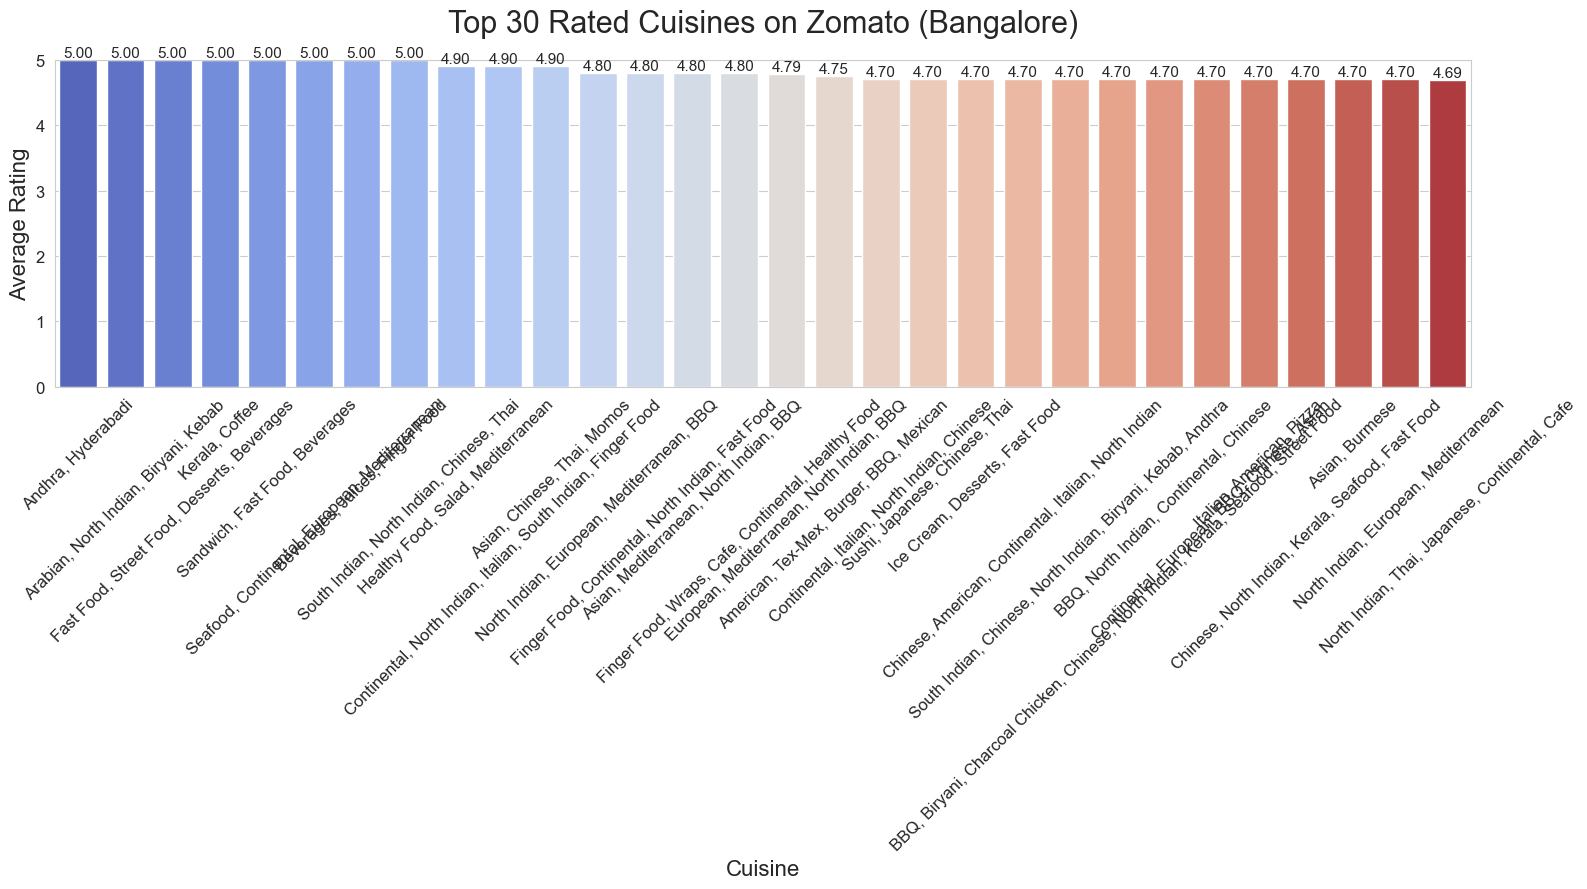

In [261]:
# Average Rating per Cuisine
rest_df = df[['cuisines', 'rate']].copy()

# Average rating per cuisine
Cuisine_data_rating = rest_df.groupby('cuisines', as_index=False)['rate'].mean()
Cuisine_data_rating.columns = ['Cuisine', 'Rating']

# Top 30 cuisines by rating
Top30_ratings = Cuisine_data_rating.sort_values(by='Rating', ascending=False).head(30)

# Plot
sns.set_style("whitegrid")
plt.figure(figsize=(16,9))
barplot = sns.barplot(x='Cuisine', y='Rating', data=Top30_ratings, palette='coolwarm')

# Add value labels on top of bars
for p in barplot.patches:
    barplot.annotate(f"{p.get_height():.2f}",
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center',
                     xytext=(0, 5),
                     textcoords='offset points',
                     fontsize=11)

plt.xlabel('Cuisine', fontsize=16)
plt.ylabel('Average Rating', fontsize=16)
plt.title('Top 30 Rated Cuisines on Zomato (Bangalore)', fontsize=22, pad=20)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.ylim(0, 5)  # Ratings are out of 5
plt.tight_layout()
plt.show()

#### Cuisine and rating of a resaurant
- Does having more number of cuisine mean higher rating of the restaurant? - yes (found latter)

In [263]:
def fun(x):
    if(type(x) == list):
        return (len(x))
    else:
        return 0
rest_df['no_of_cuisine'] = rest_df['cuisines'].str.split(',').apply(fun)

In [264]:
rest_df.groupby(['no_of_cuisine'])['rate'].mean()
#rest_df.drop('no_of_cuisine', axis=1, inplace=True)

no_of_cuisine
1    3.632971
2    3.669907
3    3.725578
4    3.845034
5    3.941075
6    4.008739
7    4.059429
8    3.934194
Name: rate, dtype: float64

Answer goes "YES"

## Finding->
American, Italian, Pizza, Biryani, Continental, Chinese, Seafood, Korean were much highly rated. Though North Indian, South Indian, Ice Cream, Mangalorean Beverages, Street Food, Cafe, Indian were the top rated but it is quite obvious for such type of restaurant to be at the top.

### top 5 cuisine famous in each of the city

In [265]:
num_top_venues = 3  # Top 3 cuisines per neighborhood

for hood in neighborhood_cns.index:
    print(f"---- {hood} ----")
    
    # Get the cuisine frequencies for the current neighborhood
    temp = neighborhood_cns.loc[hood].reset_index()
    temp.columns = ['Cuisine', 'Frequency']
    
    # Round frequency values
    temp['Frequency'] = temp['Frequency'].astype(float).round(2)
    
    # Sort descending and select top N cuisines
    top_cuisines = temp.sort_values('Frequency', ascending=False).head(num_top_venues)
    
    print(top_cuisines.reset_index(drop=True))
    print('\n')


---- BTM ----
        Cuisine  Frequency
0  North Indian     1628.0
1       Chinese     1178.0
2     Fast Food      646.0


---- Banashankari ----
        Cuisine  Frequency
0  North Indian      231.0
1       Chinese      198.0
2  South Indian      165.0


---- Banaswadi ----
        Cuisine  Frequency
0       Chinese      178.0
1  North Indian      144.0
2  South Indian      100.0


---- Bannerghatta Road ----
        Cuisine  Frequency
0  North Indian      511.0
1       Chinese      369.0
2     Fast Food      193.0


---- Basavanagudi ----
        Cuisine  Frequency
0  South Indian      170.0
1  North Indian      134.0
2     Fast Food      116.0


---- Basaveshwara Nagar ----
        Cuisine  Frequency
0  North Indian       55.0
1       Chinese       44.0
2  South Indian       29.0


---- Bellandur ----
        Cuisine  Frequency
0  North Indian      530.0
1       Chinese      298.0
2       Biryani      202.0


---- Bommanahalli ----
        Cuisine  Frequency
0  North Indian       9

Visualizing the same using ChatGPT code->

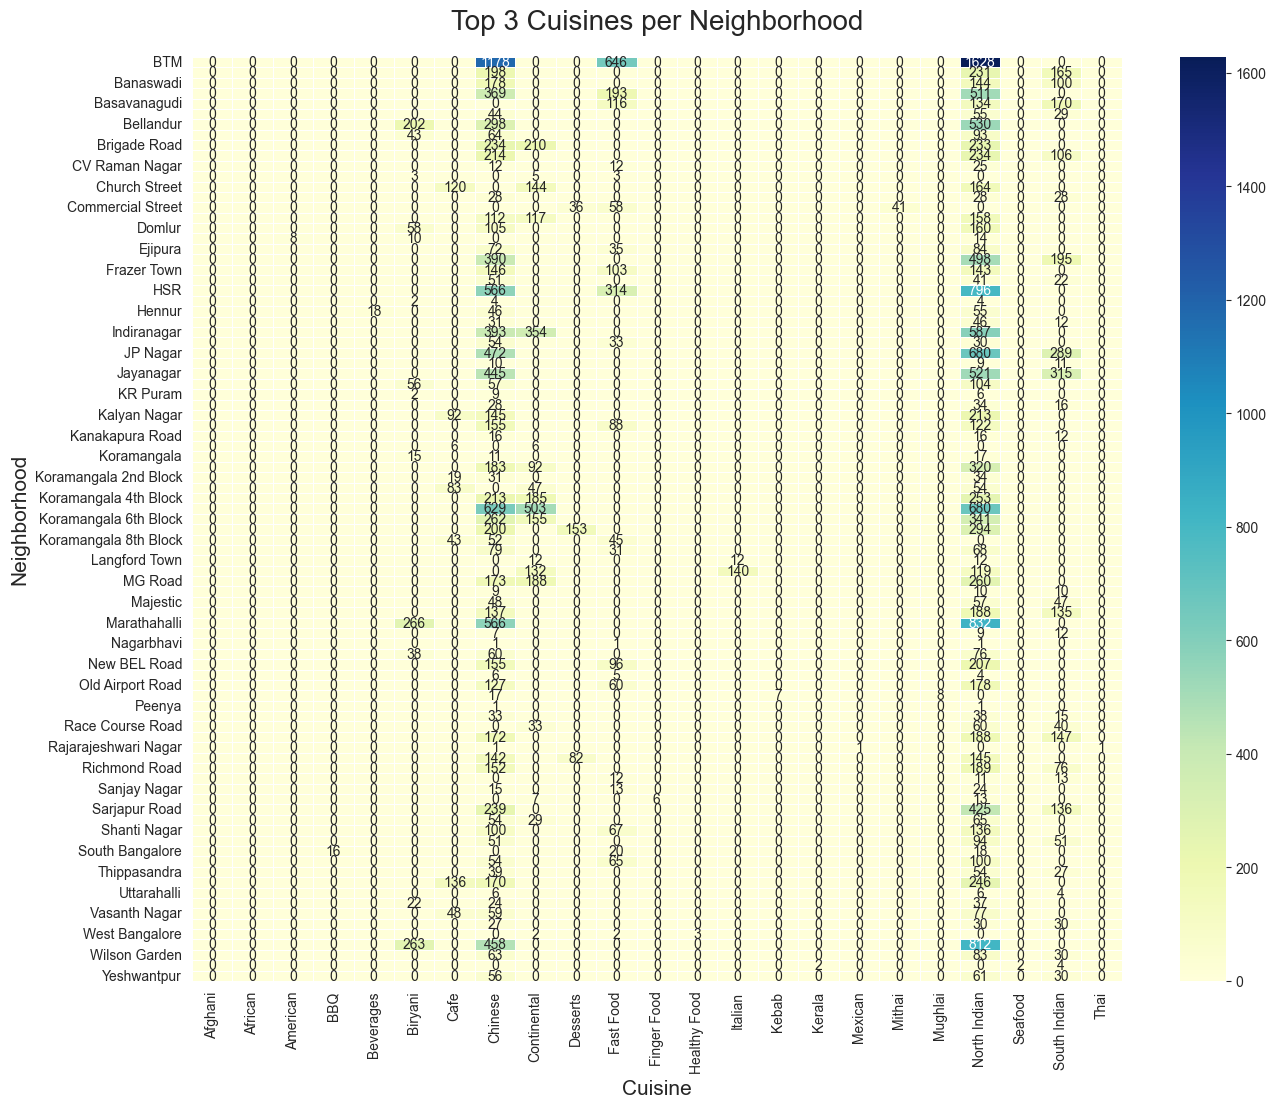

In [266]:
# Create a dataframe to hold only the top 3 cuisines per neighborhood
top_cuisines_per_hood = pd.DataFrame()

num_top_venues = 3

for hood in neighborhood_cns.index:
    temp = neighborhood_cns.loc[hood].reset_index()
    temp.columns = ['Cuisine', 'Frequency']
    temp['Frequency'] = temp['Frequency'].astype(float)
    top = temp.sort_values('Frequency', ascending=False).head(num_top_venues)
    top['Neighborhood'] = hood
    top_cuisines_per_hood = pd.concat([top_cuisines_per_hood, top], ignore_index=True)

# Pivot the dataframe for heatmap
heatmap_data = top_cuisines_per_hood.pivot(index='Neighborhood', columns='Cuisine', values='Frequency').fillna(0)

# Plot heatmap
plt.figure(figsize=(15, 12))
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="YlGnBu", linewidths=0.5)
plt.title("Top 3 Cuisines per Neighborhood", fontsize=20, pad=20)
plt.xlabel("Cuisine", fontsize=15)
plt.ylabel("Neighborhood", fontsize=15)
plt.show("top_cuisines_heatmap")

### top 3 cuisines per neighborhood

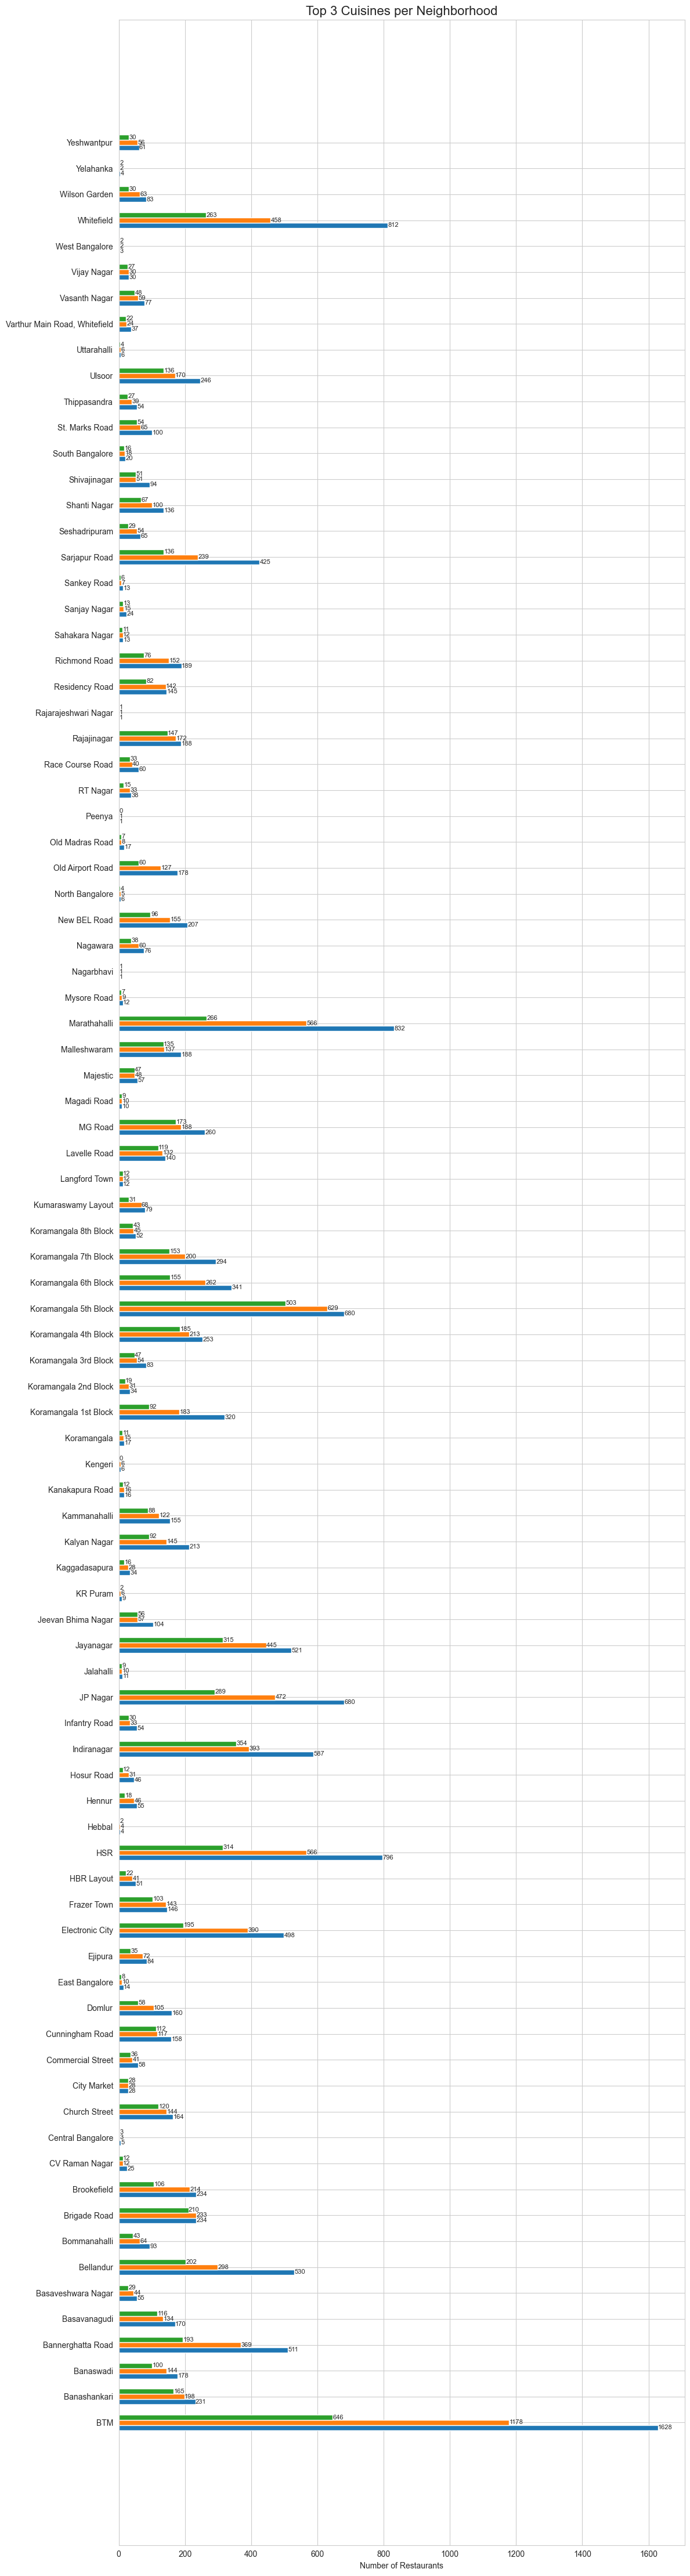

In [267]:
num_top_venues = 3

fig, ax = plt.subplots(figsize=(12, len(neighborhood_cns)*0.5))

y_pos = np.arange(len(neighborhood_cns))
bar_height = 0.2
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for i, hood in enumerate(neighborhood_cns.index):
    top_cuisines = neighborhood_cns.loc[hood].sort_values(ascending=False).head(num_top_venues)
    for j, (cuisine, freq) in enumerate(top_cuisines.items()):
        ax.barh(y_pos[i] + j*bar_height, freq, height=bar_height, color=colors[j])
        ax.text(freq + 1, y_pos[i] + j*bar_height, str(freq), va='center', fontsize=8)

ax.set_yticks(y_pos + bar_height)
ax.set_yticklabels(neighborhood_cns.index)
ax.set_xlabel("Number of Restaurants")
ax.set_title("Top 3 Cuisines per Neighborhood", fontsize=16)
plt.tight_layout()
plt.show("top_cuisines_barplot")

### Cuisine WordCloud

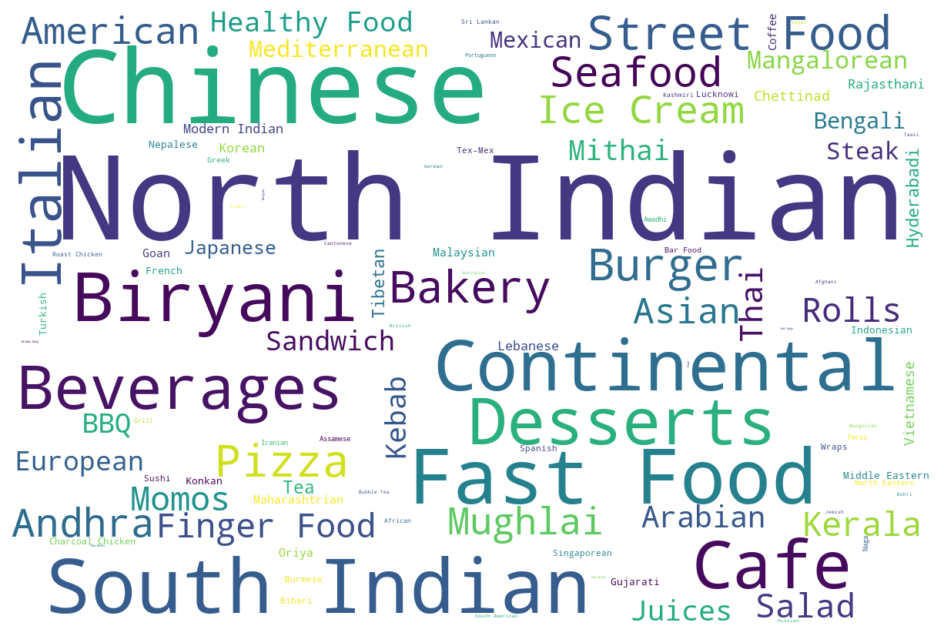

In [268]:
# Assuming neighborhood_cns has neighborhoods as index and cuisines as columns
cuisine_grouped = neighborhood_cns.groupby(neighborhood_cns.index).sum()
# Sum frequencies of each cuisine across all neighborhoods
cuisine_freq = cuisine_grouped.iloc[:, 1:].sum(axis=0).to_dict()

# Generate wordcloud
wordcloud = WordCloud(width=1200, height=800, relative_scaling=0.5, background_color='white').generate_from_frequencies(cuisine_freq)

# Plot
plt.figure(figsize=(12,8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show("cuisine_wordcloud")

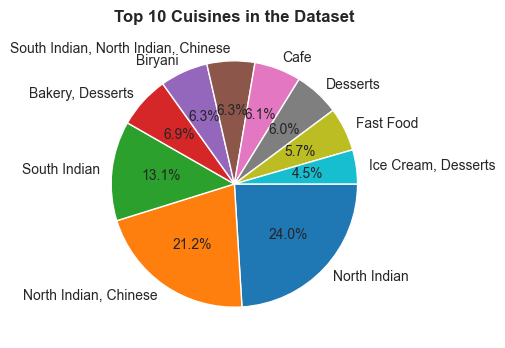

In [270]:
# Top 10 cuisines
top_10_cuisines = df['cuisines'].value_counts().sort_values(ascending=False)[:10]

# Plotting
plt.figure(figsize=(4, 4))
plt.pie(top_10_cuisines, labels=top_10_cuisines.index, autopct='%1.1f%%', counterclock=False)
plt.title('Top 10 Cuisines in the Dataset', fontweight='bold')
plt.show()

#### EDA done!
- we will import this dataset for further process -> PreProcessing, Model Building etc.

In [271]:
df.head(1)

,name,online_order,book_table,rate,votes,location,rest_type,cuisines,approx_cost,reviews_list,type,rating_group,location_latitude,location_longitude,cuisines_list
0,Jalsa,1,1,4.1,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800,"[(Rated 4.0, RATED\n A beautiful place to din...",Buffet,3 to 4.2,12.92782,77.556621,"[North Indian, Mughlai, Chinese]"


In [272]:

# Dropping unncessary columns
df_clean = df.drop(['name', 'reviews_list', 'rating_group', 'location_latitude', 'location_longitude', 'cuisines_list'], axis = 1)

In [274]:
df_clean.head(2)

,online_order,book_table,rate,votes,location,rest_type,cuisines,approx_cost,type
0,1,1,4.1,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800,Buffet
1,1,0,4.1,787,Banashankari,Casual Dining,"Chinese, North Indian, Thai",800,Buffet


Saving final dataset in artiacts folder (will .dvc it later)

In [275]:
import joblib
joblib.dump(df_clean.reset_index(drop=True), "/Users/mac/Desktop/Desktop_Files/Projects/Zomato Restaurant Rating Prediction/artifacts/df_clean.pkl")

['/Users/mac/Desktop/Desktop_Files/Projects/Zomato Restaurant Rating Prediction/artifacts/df_clean.pkl']